# Stock Price Prediction 
---
**Структура на Проектот:**
1.  Вчитување и прва инспекција на датасетот
2.  Длабока EDA (Exploratory Data Analysis)
3.  Детекција и обработка на Outliers (IQR + Z-Score)
4.  Preprocessing — Window Size, Feature Engineering, Скалирање
5.  Корелациска анализа
6.  Train/Test Split (хронолошки)
7.  Тренирање на ML Модели (RF, KNN, SVM, XGBoost)
8.  Временска Серија — ARIMA
9.  Длабоко учење — LSTM
10. Евалуација и споредба на сите модели
11. Анализа на перформансите во тест периодот (Јануари 2024)

##  1. Вчитување на библиотеки

In [99]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import time

# Поставување на фиксиран seed за реплицираност на резултатите
import random
def set_all_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)



# ML модели
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Временска серија — ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Длабоко учење — LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Активирај го семето веднаш
set_all_seeds(42)

# Визуелен стил
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")

print("✅ Сите библиотеки се успешно вчитани.")
print(f"   TensorFlow верзија: {tf.__version__}")   
print(f"   NumPy верзија:      {np.__version__}")
print(f"   Pandas верзија:     {pd.__version__}")


✅ Сите библиотеки се успешно вчитани.
   TensorFlow верзија: 2.21.0
   NumPy верзија:      2.3.4
   Pandas верзија:     2.3.3


##  2. Вчитување и прва анализа на датасетот

In [100]:
# 1. Дефинирање на точните релативни патеки
base_dir = os.getcwd()
stocks_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_stocks.csv')
index_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_index.csv')
companies_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_companies.csv')

# 2. Вчитување на точните фајлови во точните варијабли
df_stocks_raw = pd.read_csv(stocks_path)
df_index_raw = pd.read_csv(index_path)
df_companies_raw = pd.read_csv(companies_path)

print(" Сите три CSV фајлови се успешно вчитани во меморијата.")

 Сите три CSV фајлови се успешно вчитани во меморијата.


Вчитување на sp500_companies.csv

In [101]:
print("=== Вчитување НА COMPANIES ДАТАСЕТОТ ===")
print(f"Димензии: {df_companies_raw.shape[0]} компании и {df_companies_raw.shape[1]} мета-колони.\n")
print("Првите 3 реда од табелата:")
display(df_companies_raw.head(3))

print("\nКолони кои се достапни за компаниите:")
print(df_companies_raw.columns.tolist())

=== Вчитување НА COMPANIES ДАТАСЕТОТ ===
Димензии: 502 компании и 16 мета-колони.

Првите 3 реда од табелата:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401



Колони кои се достапни за компаниите:
['Exchange', 'Symbol', 'Shortname', 'Longname', 'Sector', 'Industry', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Longbusinesssummary', 'Weight']


Анализа на sp500_index.csv

In [102]:
print("=== Вчитување НА S&P 500 INDEX ДАТАСЕТОТ ===")
print(f"Димензии: {df_index_raw.shape[0]} работни денови на берзата.\n")
print("Првите 5 денови од историјата на индексот:")
display(df_index_raw.head(5))

# Статистички преглед на индексот
print("\nОсновна статистика за вредноста на индексот:")
display(df_index_raw.describe())

=== Вчитување НА S&P 500 INDEX ДАТАСЕТОТ ===
Димензии: 2517 работни денови на берзата.

Првите 5 денови од историјата на индексот:


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57



Основна статистика за вредноста на индексот:


,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


Вчитување на sp500_stocks.csv

In [103]:
print("=== Вчитување НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===")
print(f"Вкупен број на записи за сите акции: {df_stocks_raw.shape[0]:,}")
print(f"Број на колони: {df_stocks_raw.shape[1]}\n")

print("🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:")
nan_counts = df_stocks_raw.isnull().sum()
display(nan_counts[nan_counts > 0])

print("\nПример од првите 5 редови во табелата:")
display(df_stocks_raw.head(5))

=== Вчитување НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===
Вкупен број на записи за сите акции: 1,891,536
Број на колони: 8

🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:


Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64


Пример од првите 5 редови во табелата:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
df_stocks_raw[df_stocks_raw['Close'].notna()]

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0
...,...,...,...,...,...,...,...,...
1876459,2024-12-16,XYL,120.779999,120.779999,122.570000,120.000000,120.720001,1515900.0
1876460,2024-12-17,XYL,120.769997,120.769997,121.760002,119.730003,119.730003,2009200.0
1876461,2024-12-18,XYL,116.919998,116.919998,121.559998,116.879997,120.790001,1638500.0
1876462,2024-12-19,XYL,116.430000,116.430000,118.919998,116.129997,117.440002,1708000.0


Филтрирање и спојување на податоците 

🎉 Успешно креиран споениот сет податоци за AAPL!

  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       0 non-null      datetime64[ns]
 1   Symbol     0 non-null      object        
 2   Adj Close  0 non-null      float64       
 3   Close      0 non-null      float64       
 4   High       0 non-null      float64       
 5   Low        0 non-null      float64       
 6   Open       0 non-null      float64       
 7   Volume     0 non-null      float64       
 8   S&P500     0 non-null      float64       
 9   Longname   0 non-null      object        
 10  Sector     0 non-null      object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 132.0+ bytes

  ПРЕОСТАНАТИ MISSING VALUES
✅ Нема missing values!

  ДЕСКРИПТИВНА СТАТИСТИКА


,Date,Adj Close,Close,High,Low,Open,Volume,S&P500
count,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


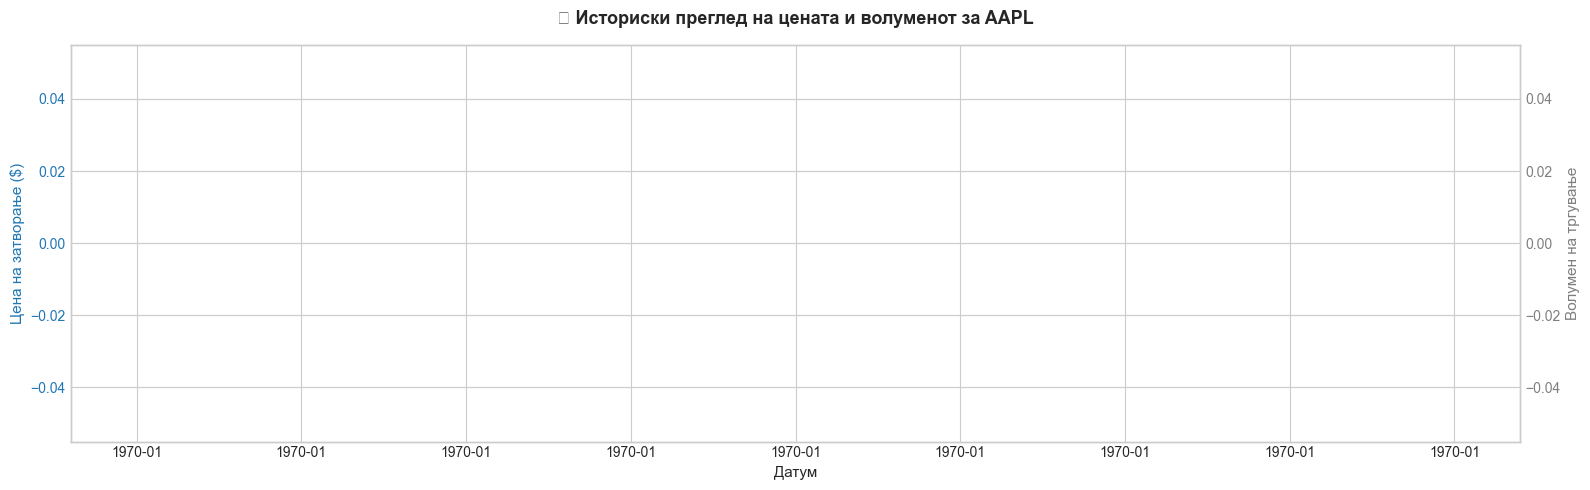

In [105]:
# =====================================================================
# 1. ПРВО КРЕИРАЊЕ НА ФИНАЛНАТА ТАБЕЛА (Филтрирање за Тесла и Мерџ на 3-те фајлови)
# =====================================================================
TICKER = 'AAPL'

# Чистење од празни места во колоните на главниот фајл
df_stocks_raw.columns = df_stocks_raw.columns.str.strip()
df_stocks_raw.dropna(subset=['Symbol'], inplace=True)
df_stocks_raw['Symbol'] = df_stocks_raw['Symbol'].astype(str).str.strip()

# Издвојување само на податоците за Тесла
df = df_stocks_raw[df_stocks_raw['Symbol'].str.upper() == TICKER.upper()].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Тргање на денови каде што нема цена на затворање
df.dropna(subset=['Close'], inplace=True)

# А) Спојување со индексот (по Датум)
df_index_raw['Date'] = pd.to_datetime(df_index_raw['Date'])
df = pd.merge(df, df_index_raw, on='Date', how='left', suffixes=('', '_index'))

# Б) Спојување со метаподатоците за компаниите (по твоите точни колони: Symbol, Longname, Sector)
df_companies_raw['Symbol'] = df_companies_raw['Symbol'].astype(str).str.strip()
df = pd.merge(df, df_companies_raw[['Symbol', 'Longname', 'Sector']], on='Symbol', how='left')

# ✨ НАШАТА ПАМЕТНА КОРЕКЦИЈА: Ги бришеме деновите каде пазарниот индекс е празен (пред декември 2014)
df.dropna(subset=['S&P500'], inplace=True)

# Финално ресетирање на индексите по чистењето
df.reset_index(drop=True, inplace=True)

print(f"🎉 Успешно креиран споениот сет податоци за {TICKER}!\n")

# =====================================================================
# 2. ТВОЈОТ КОД ЗА ИНФОРМАЦИИ И ДЕСКРИПТИВНА СТАТИСТИКА
# =====================================================================
print("=" * 60)
print("  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("  ПРЕОСТАНАТИ MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Бројка': missing, 'Процент (%)': missing_pct})
print(missing_df[missing_df['Бројка'] > 0] if missing.sum() > 0 else "✅ Нема missing values!")

print("\n" + "=" * 60)
print("  ДЕСКРИПТИВНА СТАТИСТИКА")
print("=" * 60)
display(df.describe().round(4))

# =====================================================================
# 3. ТВОЈОТ КОД ЗА ВИЗУЕЛИЗАЦИЈА
# =====================================================================
fig, ax1 = plt.subplots(figsize=(16, 5))

# Прва оска за Close цената
color = 'tab:blue'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена на затворање ($)', color=color, fontsize=11)
ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Втора оска за Волуменот (со споделена х-оска)
ax2 = ax1.twinx()  
color = 'tab:gray'
ax2.set_ylabel('Волумен на тргување', color=color, fontsize=11)
ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.15, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"📈 Историски преглед на цената и волуменот за {TICKER}", fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

##  3. Длабока EDA (Exploratory Data Analysis)



Историски тренд на цена и волумен

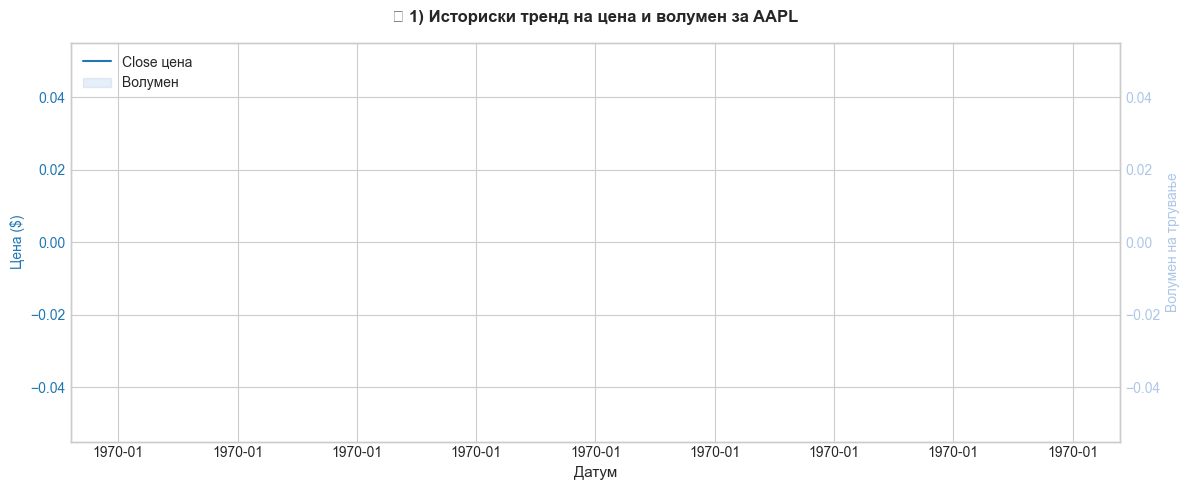

In [106]:

# Креирање на посебен график за цена и волумен
fig, ax1 = plt.subplots(figsize=(12, 5))

# Прва оска за сината линија (Close цена)
color = '#1f77b4'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена ($)', color=color)
p1, = ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Втора оска (twinx) за светлосната сенка во позадина (Волумен)
ax2 = ax1.twinx()
color = '#aec7e8'
ax2.set_ylabel('Волумен на тргување', color=color)
p2 = ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.3, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)

# Обединување на легендите во едно заедничко прозорче
ax1.legend([p1, p2], [p1.get_label(), p2.get_label()], loc='upper left', fontsize=10)

plt.title(f'📈 1) Историски тренд на цена и волумен за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Дистрибуција на цената (Хистограм)

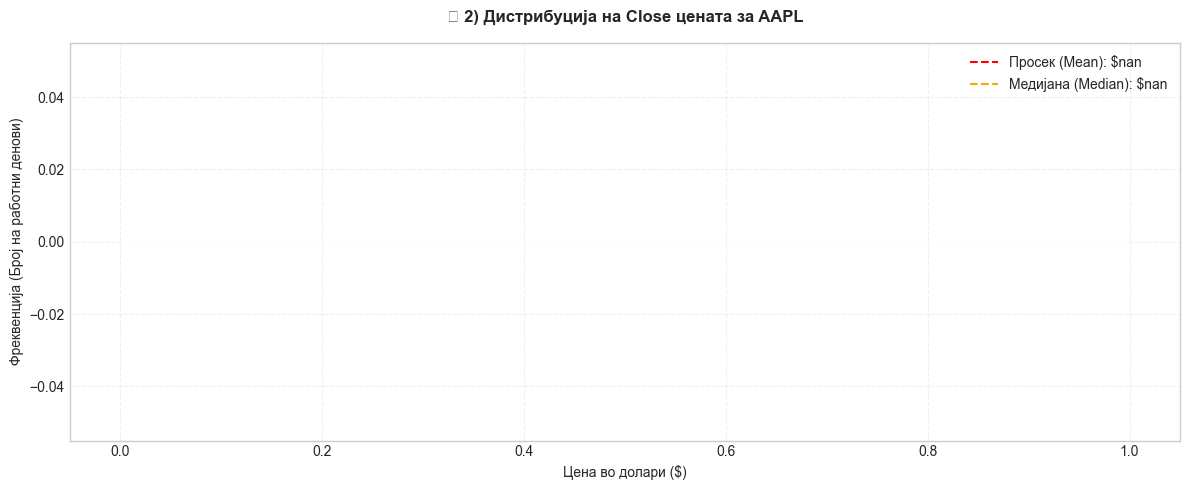

In [107]:
# Креирање график за дистрибуција (Хистограм)
plt.figure(figsize=(12, 5))

# Цртање на хистограмот со 50 колони (bins)
plt.hist(df['Close'], bins=50, color='#2ca02c', edgecolor='white', alpha=0.8)

# Додавање на црвена линија за Просекот и портокалова за Медијаната
plt.axvline(df['Close'].mean(), color='red', linestyle='--', linewidth=1.5, 
            label=f"Просек (Mean): ${df['Close'].mean():.2f}")
plt.axvline(df['Close'].median(), color='orange', linestyle='--', linewidth=1.5, 
            label=f"Медијана (Median): ${df['Close'].median():.2f}")

plt.title(f'📊 2) Дистрибуција на Close цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.xlabel('Цена во долари ($)')
plt.ylabel('Фреквенција (Број на работни денови)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Годишен просек на цената

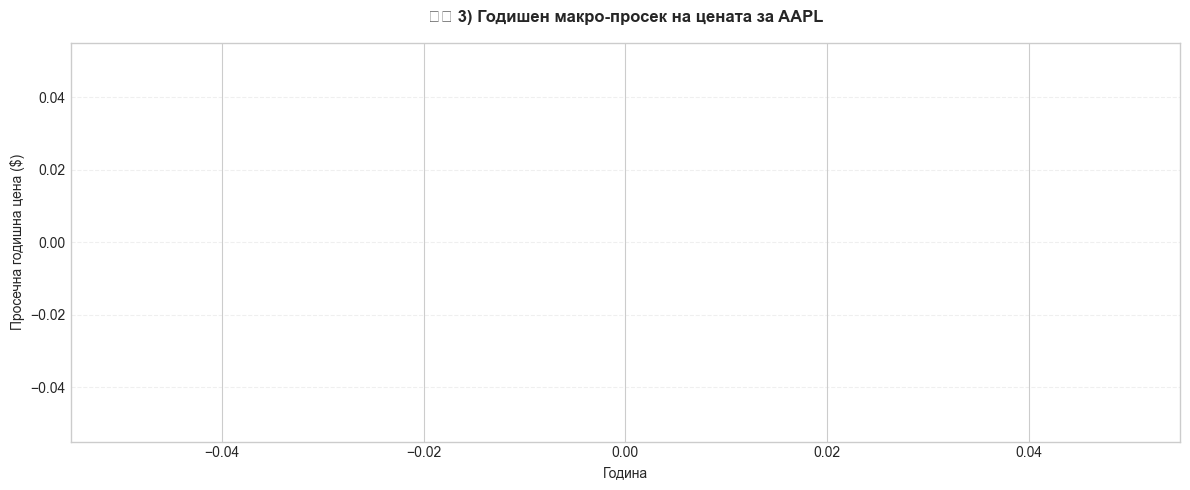

In [108]:
# Привремено извлекување на годината од датумот за групирање
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Close'].mean()

# Креирање на столбест график
plt.figure(figsize=(12, 5))
plt.bar(yearly.index.astype(str), yearly.values, color='#9467bd', edgecolor='white', alpha=0.85)

plt.title(f'🏛️ 3) Годишен макро-просек на цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Година')
plt.ylabel('Просечна годишна цена ($)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Бришење на привремената колона за да не го валкаме датасетот
df.drop(columns=['Year'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Сезонски просек по месеци (Seasonality)

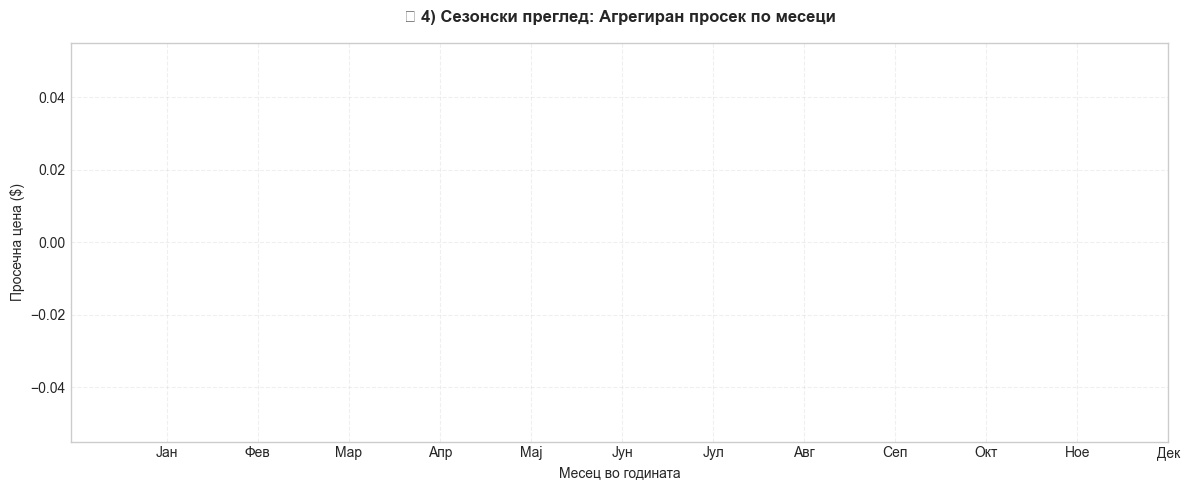

In [ ]:
# Привремено извлекување на месецот
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['Close'].mean()
months_labels = ['Јан','Фев','Мар','Апр','Мај','Јун','Јул','Авг','Сеп','Окт','Ное','Дек']

# Креирање линиски график со точки за секој месец
plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), monthly.values, marker='o', color='#d62728', linewidth=2, markersize=6)

plt.title(f'📅 4) Сезонски преглед: Агрегиран просек по месеци за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xticks(range(1, 13), months_labels, fontsize=10)
plt.xlabel('Месец во годината')
plt.ylabel('Просечна цена ($)')
plt.grid(True, linestyle='--', alpha=0.3)

# Финално чистење на помошната колона Month
df.drop(columns=['Month'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Пресметка на приноси

In [110]:
df['Daily_Return_Raw'] = df['Close'].pct_change()

# Подготовка на податоци во проценти (%) за подобра читливост на графиконите
returns_pct = df['Daily_Return_Raw'].dropna() * 100

print(" Дневните приноси се успешно пресметани!")

 Дневните приноси се успешно пресметани!


Дистрибуција на приноси

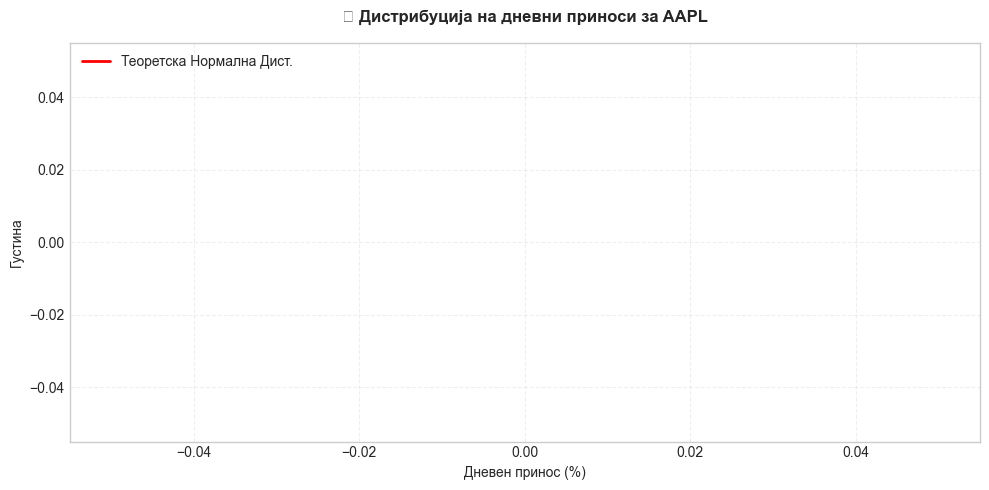

In [111]:
plt.figure(figsize=(10, 5))

# Цртање на реалниот хистограм (сините столбови)
plt.hist(returns_pct, bins=80, color='#1f77b4', edgecolor='white', alpha=0.7, density=True)

# Креирање на Црвената линија (Теоретска Нормална Дистрибуција)
mu_pct, sigma_pct = returns_pct.mean(), returns_pct.std()
x = np.linspace(returns_pct.min(), returns_pct.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu_pct, sigma_pct), 'r-', linewidth=2, label='Теоретска Нормална Дист.')

plt.title(f'📉 Дистрибуција на дневни приноси за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Дневен принос (%)')
plt.ylabel('Густина')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Boxplot и Ролинг Волатилност

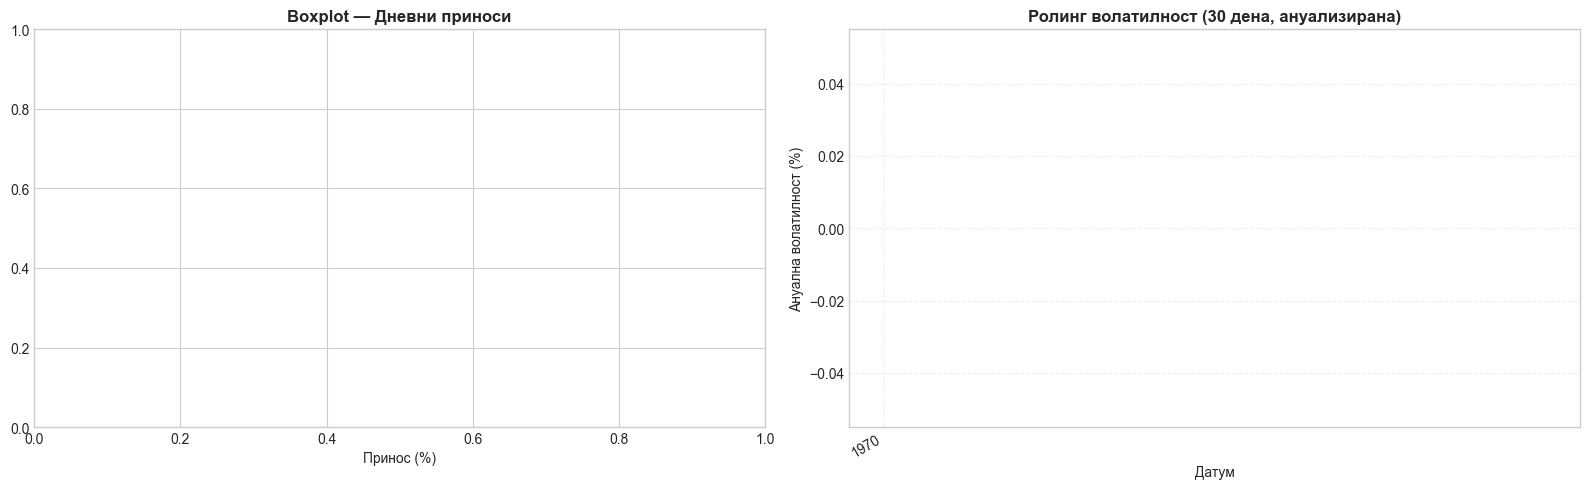

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot (Мерење на екстремни денови во проценти)
sns.boxplot(x=returns_pct, ax=ax1, color='salmon')
ax1.set_title('Boxplot — Дневни приноси', fontweight='bold')
ax1.set_xlabel('Принос (%)')

# 2. Ролинг волатилност (30 дена, ануализирана)
rolling_vol = df['Daily_Return_Raw'].rolling(30).std() * np.sqrt(252) * 100
ax2.plot(df['Date'], rolling_vol, color='#ff7f0e', linewidth=1.2, label='30д Ролинг Волатилност')
ax2.set_title('Ролинг волатилност (30 дена, ануализирана)', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('Ануална волатилност (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Статистички бројки и пополнување на дупки

In [113]:
# Пополнување на првиот ред (кој стана NaN бидејќи првиот ден нема претходен ден со кој би се споредил)
df['Daily_Return_Raw'] = df['Daily_Return_Raw'].fillna(0)

print(f"=" * 50)
print(f" ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ")
print(f"=" * 50)
print(f"   Просечен дневен принос:  {mu_pct:.4f}%")
print(f"   Стандардна девијација:   {sigma_pct:.4f}%")
print(f"   Skewness (асиметрија):   {returns_pct.skew():.4f}")
print(f"   Kurtosis:     {returns_pct.kurtosis():.4f}")
print(f"=" * 50)

 ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ
   Просечен дневен принос:  nan%
   Стандардна девијација:   nan%
   Skewness (асиметрија):   nan
   Kurtosis:     nan


##  4. Детекција и обработка на Outliers

Математичка пресметка и детекција (IQR и Z-Score).


In [114]:
# Креираме привремена серија во проценти (%) за поконзистентен приказ
returns_pct = df['Daily_Return_Raw'] * 100

# ── 1) IQR Метод (Во проценти) ──
Q1 = returns_pct.quantile(0.25)
Q3 = returns_pct.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr_idx = (returns_pct < lower_iqr) | (returns_pct > upper_iqr)
outliers_iqr = df[outliers_iqr_idx]

# ── 2) Z-Score Метод (Врз основа на оригиналните приноси) ──
z_scores = np.abs(stats.zscore(df['Daily_Return_Raw']))
outliers_zscore = df[z_scores > 3]

print("=" * 60)
print("  РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS")
print("=" * 60)
print(f"IQR Метод       — Граници: [{lower_iqr:.2f}%, {upper_iqr:.2f}%]")
print(f"                — Пронајдени аутлаери: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"Z-Score (>3σ)  — Пронајдени аутлаери: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")
print("=" * 60)

  РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS
IQR Метод       — Граници: [nan%, nan%]


ZeroDivisionError: division by zero

Визуелизација на аномалиите (Scatter Plots)

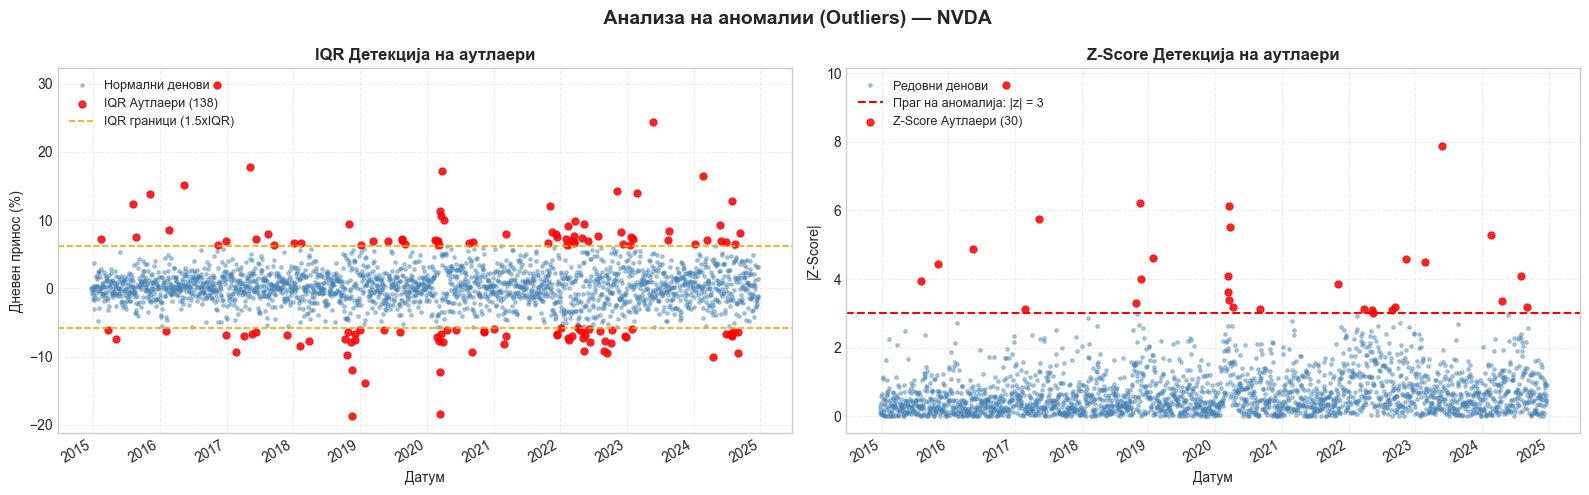

In [ ]:
# Креирање на двата графикони еден до друг
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f' Анализа на аномалии (Outliers) — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# График 1: IQR Детекција
ax1 = axes[0]
ax1.scatter(df['Date'], returns_pct, s=6, color='steelblue', alpha=0.4, label='Нормални денови')
ax1.scatter(outliers_iqr['Date'], outliers_iqr['Daily_Return_Raw']*100, s=25, color='red', alpha=0.8, label=f'IQR Аутлаери ({len(outliers_iqr)})')
ax1.axhline(lower_iqr, color='orange', linestyle='--', linewidth=1.2, label='IQR граници (1.5xIQR)')
ax1.axhline(upper_iqr, color='orange', linestyle='--', linewidth=1.2)
ax1.set_title('IQR Детекција на аутлаери', fontweight='bold')
ax1.set_xlabel('Датум')
ax1.set_ylabel('Дневен принос (%)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# График 2: Z-Score Детекција
ax2 = axes[1]
ax2.scatter(df['Date'], z_scores, s=6, color='steelblue', alpha=0.4, label='Редовни денови')
ax2.axhline(3, color='red', linestyle='--', linewidth=1.5, label='Праг на аномалија: |z| = 3')
ax2.scatter(df.loc[z_scores > 3, 'Date'], z_scores[z_scores > 3], s=25, color='red', alpha=0.8, label=f'Z-Score Аутлаери ({len(outliers_zscore)})')
ax2.set_title('Z-Score Детекција на аутлаери', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('|Z-Score|')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

Топ 10 Најлуди денови во историјата на Тесла

In [ ]:
print("\n Топ 10 денови со најекстремни пазарни движења:")
top_outliers = outliers_iqr.copy()
top_outliers['Daily_Return (%)'] = (top_outliers['Daily_Return_Raw'] * 100).round(2)
top_outliers['|Return (%)|'] = top_outliers['Daily_Return (%)'].abs()

# Приказ на средена табела во проценти
display(top_outliers.sort_values('|Return (%)|', ascending=False)
        [['Date', 'Close', 'Volume', 'Daily_Return (%)']]
        .head(10).reset_index(drop=True))

print("\n Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува")
print("   хронолошкиот континуитет и интегритетот на временската серија.")


 Топ 10 денови со најекстремни пазарни движења:


,Date,Close,Volume,Daily_Return (%)
0,2016-11-11,2.199250,2.175344e+09,29.81
1,2023-05-25,37.980000,1.543911e+09,24.37
2,2018-11-16,4.110750,1.963520e+09,-18.76
3,2020-03-16,4.910000,7.269720e+08,-18.45
4,2017-05-10,3.032250,2.129096e+09,17.83
5,2020-03-24,6.229500,1.101644e+09,17.16
6,2024-02-22,78.538002,8.651000e+08,16.40
7,2016-05-13,1.024500,2.110256e+09,15.21
8,2022-11-10,15.750000,7.008190e+08,14.33
9,2023-02-23,23.664000,1.117995e+09,14.02



 Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува
   хронолошкиот континуитет и интегритетот на временската серија.


### 4.1 Обработка на Outliers — Capping (Winsorization)

Примена на Capping (Винзоризација)

In [ ]:
# 1. Наоѓање на оригиналните децимални граници (IQR)
q1_raw = df['Daily_Return_Raw'].quantile(0.25)
q3_raw = df['Daily_Return_Raw'].quantile(0.75)
iqr_raw = q3_raw - q1_raw
lower_raw = q1_raw - 1.5 * iqr_raw
upper_raw = q3_raw + 1.5 * iqr_raw

# 2. Примена на Capping (Ограничување) — .clip() ги заковува вредностите на границите
df['Daily_Return_Cleaned'] = df['Daily_Return_Raw'].clip(lower=lower_raw, upper=upper_raw)

# 3. Подготовка на проценти само за визуелизација
cleaned_pct = df['Daily_Return_Cleaned'] * 100
lower_pct = lower_raw * 100
upper_pct = upper_raw * 100

print(f" Capping (Winsorization) успешно применет врз приносите.")
print(f"   Математички граници за моделите: [{lower_raw:.4f}, {upper_raw:.4f}]")
print(f"   Визуелни граници во проценти:     [{lower_pct:.2f}%, {upper_pct:.2f}%]")

 Capping (Winsorization) успешно применет врз приносите.
   Математички граници за моделите: [-0.0575, 0.0626]
   Визуелни граници во проценти:     [-5.75%, 6.26%]


Верификација на исчистените податоци (Графикони)

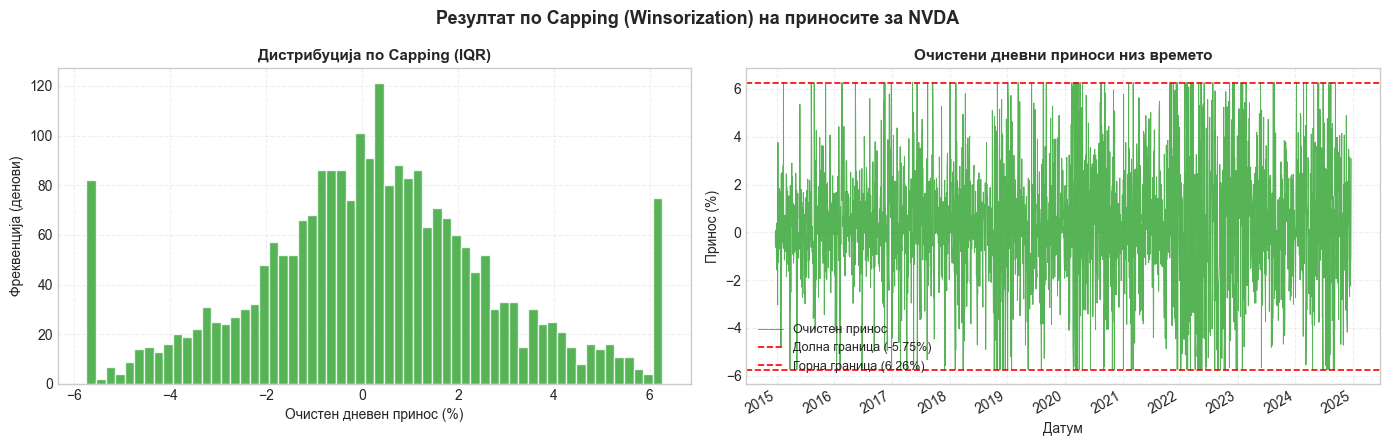

In [ ]:


# Изречно ја дефинираме фигурата и двете под-графикончиња (axes) на почетокот на ќелијата
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f' Резултат по Capping (Winsorization) на приносите за {TICKER}', fontsize=13, fontweight='bold', y=0.98)

# 1) Хистограм по Capping
axes[0].hist(cleaned_pct, bins=60, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[0].set_title('Дистрибуција по Capping (IQR)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Очистен дневен принос (%)')
axes[0].set_ylabel('Фреквенција (денови)')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2) Временски приказ по Capping
axes[1].plot(df['Date'], cleaned_pct, color='#2ca02c', linewidth=0.7, alpha=0.8, label='Очистен принос')
axes[1].axhline(lower_pct, color='red', linestyle='--', linewidth=1.2, label=f'Долна граница ({lower_pct:.2f}%)')
axes[1].axhline(upper_pct, color='red', linestyle='--', linewidth=1.2, label=f'Горна граница ({upper_pct:.2f}%)')
axes[1].set_title('Очистени дневни приноси низ времето', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Принос (%)')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Форматирање на датумите на X-оската
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## ⚙️ 5. Preprocessing — Window Size & Feature Engineering

**Window Size** е клучен хиперпараметар кај временски серии. Се однесува на 
бројот на минати денови кои ги гледаме за да го предвидиме наредниот ден.

**Вклучени карактеристики:**
- Подвижни просеци (SMA) и EMA за краткорочен и долгорочен тренд
- MACD spread (разлика на EMA за сигнали за влез/излез)
- RSI (индикатор за прекупеност / препродаденост)
- Bollinger Bands width (мерка на волатилност)
- Price momentum (моментум на движење)
- Волатилност (ролинг стандардна девијација)


Подготовка и Trend Индикатори (SMA & EMA)

In [ ]:
# ── CELL 1: Подготовка и Trend Индикатори (SMA & EMA) ──

# Креираме копија од исчистениот df за да работиме на ML карактеристиките
df_ml = df.copy()

window_short = 7
window_long = 21

# Креирање на основните подвижни просеци
df_ml['MA_7']  = df_ml['Close'].rolling(window=window_short).mean()
df_ml['MA_21'] = df_ml['Close'].rolling(window=window_long).mean()
df_ml['EMA_12'] = df_ml['Close'].ewm(span=12, adjust=False).mean()
df_ml['EMA_26'] = df_ml['Close'].ewm(span=26, adjust=False).mean()

print(" Чекор 1: Креирани се SMA и EMA карактеристиките.")

 Чекор 1: Креирани се SMA и EMA карактеристиките.


Изведени карактеристики и Bollinger Bands

In [ ]:
# ── CELL 2: Изведени карактеристики и Bollinger Bands ──

# Некорелирани карактеристики (разлики и соодноси)
df_ml['MA_Trend_Diff']      = df_ml['MA_7'] - df_ml['MA_21']           # Bullish/Bearish crossover
df_ml['EMA_Spread']         = df_ml['EMA_12'] - df_ml['EMA_26']        # MACD Spread
df_ml['Price_to_MA7_Ratio'] = df_ml['Close'] / (df_ml['MA_7'] + 1e-9) # Нормализирана позиција

# Bollinger Bands пресметки
rolling_std = df_ml['Close'].rolling(window=window_short).std()
df_ml['BB_Upper'] = df_ml['MA_7'] + 2 * rolling_std
df_ml['BB_Lower'] = df_ml['MA_7'] - 2 * rolling_std
df_ml['BB_Width'] = (df_ml['BB_Upper'] - df_ml['BB_Lower']) / (df_ml['MA_7'] + 1e-9)  # Нормализирана ширина

print(" Чекор 2: Креирани се Bollinger Bands и тренд диференцијалите.")

 Чекор 2: Креирани се Bollinger Bands и тренд диференцијалите.


Momentum & Волатилност

In [ ]:
# ── CELL 3: Momentum & Волатилност ──

# Пазарен Моментум (Брзина на промена на цената)
df_ml['Momentum_5'] = df_ml['Close'] - df_ml['Close'].shift(5)   # 5-дневен моментум
df_ml['Momentum_10'] = df_ml['Close'] - df_ml['Close'].shift(10) # 10-дневен моментум

# Ролинг волатилност (од претходно исчистените приноси)
df_ml['Volatility_7']  = df_ml['Daily_Return_Cleaned'].rolling(window=window_short).std()
df_ml['Volatility_21'] = df_ml['Daily_Return_Cleaned'].rolling(window=window_long).std()

print(" Чекор 3: Креирани се Momentum и Волатилност индикаторите.")

 Чекор 3: Креирани се Momentum и Волатилност индикаторите.


RSI Индикатор (Wilder's Smoothing)

In [ ]:
# ── CELL 4: RSI Индикатор (Wilder's Smoothing) ──

delta = df_ml['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Алфа за 14-дневен RSI според Вајлдер е 1/14
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / (avg_loss + 1e-9)
df_ml['RSI'] = 100 - (100 / (1 + rs))

print(" Чекор 4: Пресметан е точниот RSI индикатор.")

 Чекор 4: Пресметан е точниот RSI индикатор.


Лагови и Креирање на Target (Ознака за предвидување)

In [ ]:
# ── CELL 5: Лагови и Креирање на Target (Ознака за предвидување) ──

# Временски лагови (Поглед наназад)
df_ml['Close_Lag1'] = df_ml['Close'].shift(1)
df_ml['Close_Lag5'] = df_ml['Close'].shift(5)

# TARGET: Цената следниот работен ден (Што треба да предвидиме)
df_ml['Target_Price'] = df_ml['Close'].shift(-1)

print(" Чекор 5: Лаговите и Target вредноста се успешно поставени.")

 Чекор 5: Лаговите и Target вредноста се успешно поставени.


 Чистење на NaN и Финална инспекција

In [ ]:
# ── CELL 6: Чистење на NaN и Финална инспекција ──

# Бидејќи имаме rolling(21) и shift(10), првите 21 редови ќе бидат NaN. Ги бришеме за чист тренинг.
df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

print(f" FEATURE ENGINEERING Е ЦЕЛОСНО ЗАВРШЕН!\n")
print(f" Димензии на финалната матрица за Machine Learning: {df_ml.shape[0]:,} денови x {df_ml.shape[1]} колони")
print(f"\n Список на сите достапни карактеристики:")
print("-" * 65)
for index, col in enumerate(df_ml.columns, 1):
    print(f"{index:02d}. {col}")

 FEATURE ENGINEERING Е ЦЕЛОСНО ЗАВРШЕН!

 Димензии на финалната матрица за Machine Learning: 2,496 денови x 31 колони

 Список на сите достапни карактеристики:
-----------------------------------------------------------------
01. Date
02. Symbol
03. Adj Close
04. Close
05. High
06. Low
07. Open
08. Volume
09. S&P500
10. Longname
11. Sector
12. Daily_Return_Raw
13. Daily_Return_Cleaned
14. MA_7
15. MA_21
16. EMA_12
17. EMA_26
18. MA_Trend_Diff
19. EMA_Spread
20. Price_to_MA7_Ratio
21. BB_Upper
22. BB_Lower
23. BB_Width
24. Momentum_5
25. Momentum_10
26. Volatility_7
27. Volatility_21
28. RSI
29. Close_Lag1
30. Close_Lag5
31. Target_Price


### 5.1 Анализа на Window Size — Влијание врз предвидувањето

Подготовка на податоци за Window Size демонстрација

In [ ]:
# ── CELL 1: Подготовка на податоци за Window Size демонстрација ──

# Прво ги пресметуваме индикаторите на ЦЕЛИОТ df за да нема празнини кај големите прозорци (MA-200)
df_ma_demo = df.copy()

# Пресметка за првиот графикон (Различни прозорци)
ma_windows = [7, 21, 50, 200]
for w in ma_windows:
    df_ma_demo[f'MA_{w}'] = df_ma_demo['Close'].rolling(w).mean()

# Пресметка за вториот графикон (SMA vs EMA)
df_ma_demo['SMA_7'] = df_ma_demo['Close'].rolling(7).mean()
df_ma_demo['EMA_7'] = df_ma_demo['Close'].ewm(span=7, adjust=False).mean()

# СЕГА ги земаме само последните 500 записи за прегледна визуелизација
sample = df_ma_demo.tail(500)

print(" Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!")

 Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!


 Визуелизација на Moving Averages и Реактивност

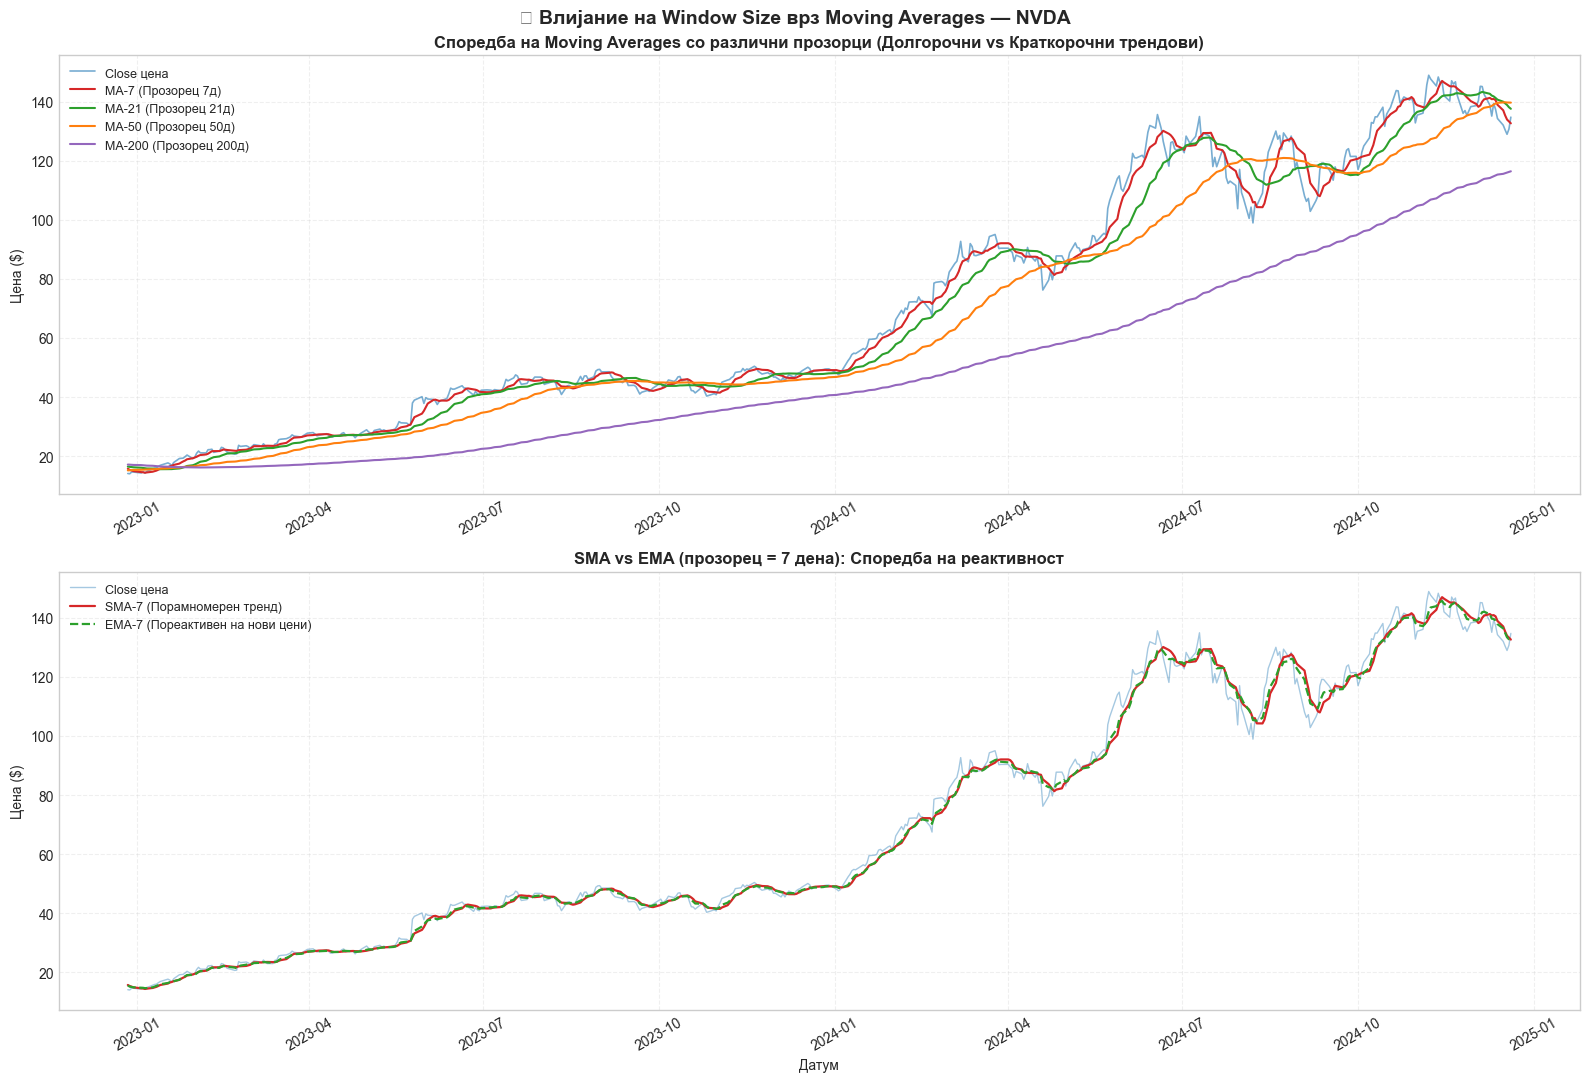

In [ ]:
# ── CELL 2: Визуелизација на Moving Averages и Реактивност ──

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle(f'📉 Влијание на Window Size врз Moving Averages — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Горен графикон: Различни MA прозорци (Линиите сега се комплетни)
axes[0].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1.2, alpha=0.6, label='Close цена')
colors_ma = {7: '#d62728', 21: '#2ca02c', 50: '#ff7f0e', 200: '#9467bd'}

for w in ma_windows:
    axes[0].plot(sample['Date'], sample[f'MA_{w}'], linewidth=1.5, label=f'MA-{w} (Прозорец {w}д)', color=colors_ma[w])

axes[0].set_title('Споредба на Moving Averages со различни прозорци (Долгорочни vs Краткорочни трендови)', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)  # Елегантно ротирање на горната оска
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2) Долен графикон: EMA vs SMA за краток прозорец (7)
axes[1].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1, alpha=0.4, label='Close цена')
axes[1].plot(sample['Date'], sample['SMA_7'], linewidth=1.6, color='#d62728', label='SMA-7 (Порамномерен тренд)')
axes[1].plot(sample['Date'], sample['EMA_7'], linewidth=1.6, color='#2ca02c', linestyle='--', label='EMA-7 (Пореактивен на нови цени)')

axes[1].set_title('SMA vs EMA (прозорец = 7 дена): Споредба на реактивност', fontweight='bold')
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Цена ($)')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)  # Елегантно ротирање на долната оска
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 6. Корелациска Анализа

Пресметка на Корелациска Матрица

In [ ]:
# ── CELL 1: Пресметка на Корелациска Матрица ──

# Дефинирање на карактеристиките кои ќе ги анализираме
feature_cols = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
                'BB_Width', 'Momentum_5', 'Volatility_7', 'RSI',
                'Close_Lag1', 'Close_Lag5', 'Target_Price']

# Пресметка на Pearson-овиот коефициент на корелација
corr = df_ml[feature_cols].corr()

print(" Чекор 1: Корелациската матрица за избраните карактеристики е успешно пресметана.")

 Чекор 1: Корелациската матрица за избраните карактеристики е успешно пресметана.


Визуелизација на Корелација и Влијание врз Target

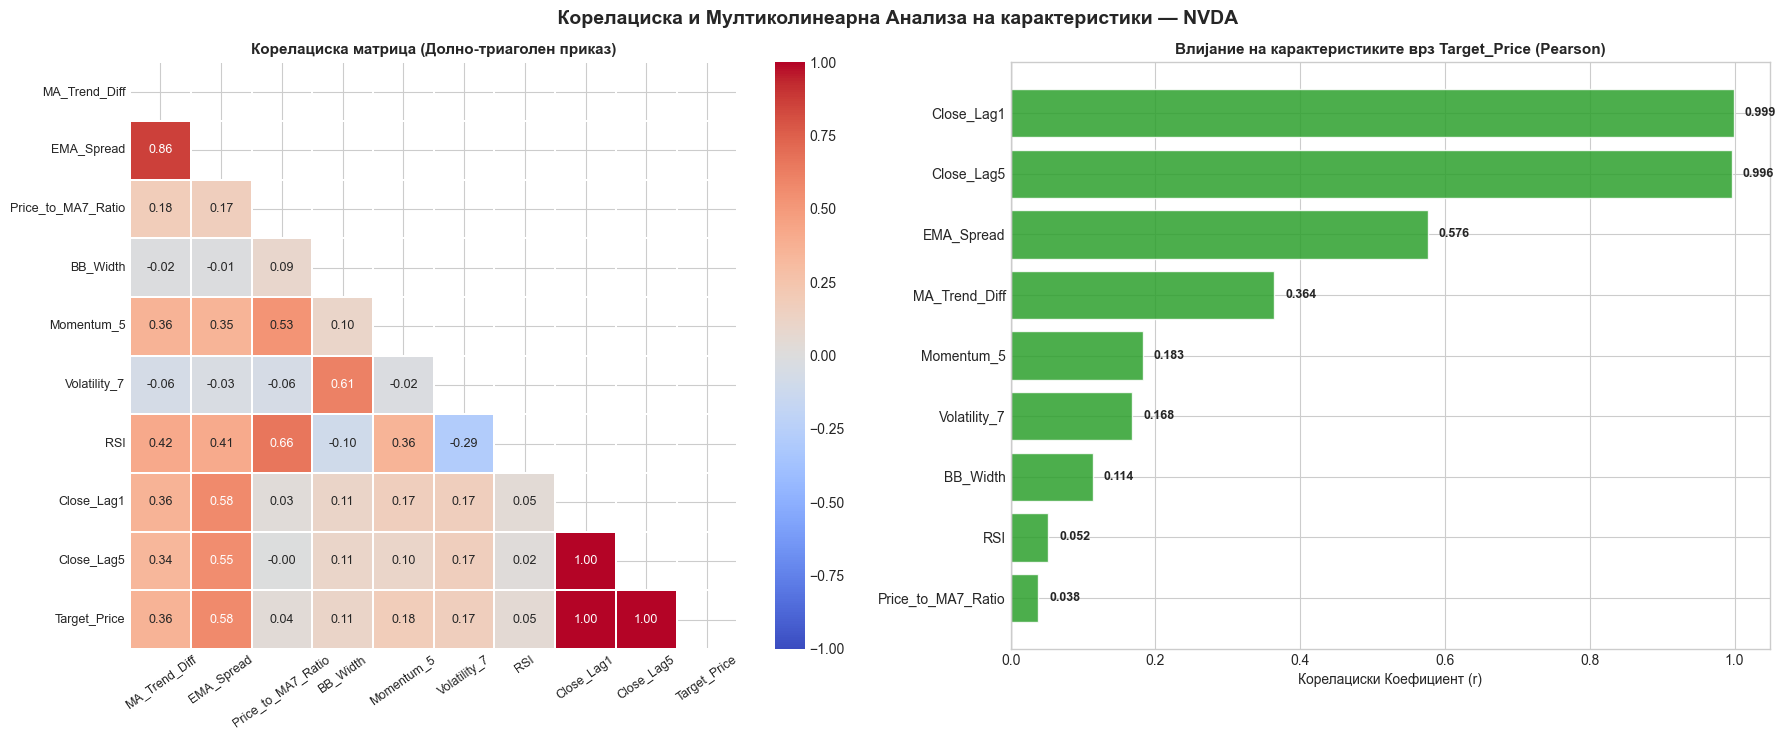

In [ ]:
# ── CELL 2: Визуелизација на Корелација и Влијание врз Target ──

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.suptitle(f' Корелациска и Мултиколинеарна Анализа на карактеристики — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Триаголна Хитмапа (Долно-триаголен приказ)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.3, ax=axes[0], mask=mask, annot_kws={"size": 9})

axes[0].set_title('Корелациска матрица (Долно-триаголен приказ)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# 2) Корелација специфично со Target променливата
target_corr = corr['Target_Price'].drop('Target_Price').sort_values(ascending=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='-')
axes[1].set_title('Влијание на карактеристиките врз Target_Price (Pearson)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Корелациски Коефициент (r)')

# Додавање на вредностите како текст на самите барови
for i, v in enumerate(target_corr.values):
    offset = 0.015 if v >= 0 else -0.015
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Автоматска Детекција на Мултиколинеарност (|r| > 0.90)

In [ ]:
# ── CELL 3: Автоматска Детекција на Мултиколинеарност (|r| > 0.90) ──

print("=" * 65)
print("  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):")
print("=" * 65)

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        # Ги проверуваме сите парови освен соодносот со самата Target_Price
        if corr.columns[i] != 'Target_Price' and corr.columns[j] != 'Target_Price':
            if abs(corr.iloc[i,j]) > 0.90:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

if high_corr:
    for a, b, r in high_corr:
        print(f"  Висок ризик: {a} ↔ {b} | r = {r:.4f}")
else:
    print(" ✅ Одлично! Нема пронајдено критична мултиколинеарност меѓу влезните карактеристики.")
print("=" * 65)

  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):
  Висок ризик: Close_Lag1 ↔ Close_Lag5 | r = 0.9973


Чистење на мултиколинеарната карактеристика

In [ ]:
# Чистење на мултиколинеарната карактеристика
df_ml.drop(columns=['Close_Lag5'], inplace=True, errors='ignore')

print(" Успешно исфрлена колоната 'Close_Lag5' за да се елиминира мултиколинеарноста.")
print(f"Нови димензии на датасетот: {df_ml.shape[0]} денови x {df_ml.shape[1]} колони")

 Успешно исфрлена колоната 'Close_Lag5' за да се елиминира мултиколинеарноста.
Нови димензии на датасетот: 2496 денови x 30 колони


## ✂️ 7. Train/Test Split — Хронолошки

Кај временски серии е **забрането** да се користи рандом сплит.  
Секогаш тренираме на минатото и тестираме на иднината (80/20).


Хронолошки сплит (Спречување на Look-Ahead Bias)

In [ ]:
# ── CELL 1: Хронолошки сплит (Спречување на Look-Ahead Bias) ──

# Дефинирање на feature columns (без 'Close' за да избегнеме leakage)
FEATURE_COLS = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
                'BB_Width', 'Momentum_5', 'Momentum_10',
                'Volatility_7', 'Volatility_21', 'RSI',
                'Daily_Return_Cleaned', 'Close_Lag1',]

X = df_ml[FEATURE_COLS]
y = df_ml['Target_Price']

# Хронолошки сплит на 80% за тренирање и 20% за тестирање
split_idx = int(len(df_ml) * 0.80)

X_train_raw = X.iloc[:split_idx]
X_test_raw  = X.iloc[split_idx:]
y_train     = y.iloc[:split_idx]
y_test      = y.iloc[split_idx:]

print(f" Хронолошки сплит: 80% тренирање / 20% тестирање")
print(f"   Тренинг период:  {df_ml['Date'].iloc[0].date()} → {df_ml['Date'].iloc[split_idx-1].date()} ({len(y_train)} денови)")
print(f"   Тест период:     {df_ml['Date'].iloc[split_idx].date()} → {df_ml['Date'].iloc[-1].date()} ({len(y_test)} денови)")

 Хронолошки сплит: 80% тренирање / 20% тестирање
   Тренинг период:  2015-01-22 → 2022-12-22 (1996 денови)
   Тест период:     2022-12-23 → 2024-12-19 (500 денови)


Визуелен приказ на поделбата

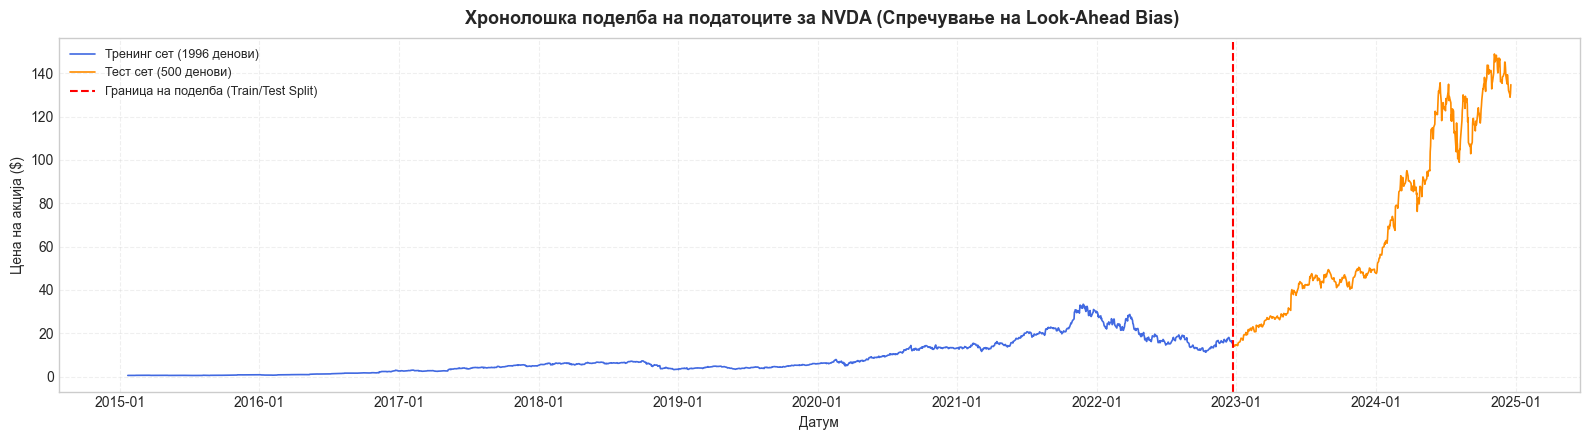

In [ ]:
# ── CELL 2: Визуелен приказ на поделбата ──

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(df_ml['Date'].iloc[:split_idx], y_train, label=f'Тренинг сет ({len(y_train)} денови)', color='royalblue', linewidth=1.2)
ax.plot(df_ml['Date'].iloc[split_idx:], y_test,  label=f'Тест сет ({len(y_test)} денови)',     color='darkorange', linewidth=1.2)
ax.axvline(df_ml['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=1.5, label='Граница на поделба (Train/Test Split)')

ax.set_title(f' Хронолошка поделба на податоците за {TICKER} (Спречување на Look-Ahead Bias)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Цена на акција ($)')
ax.set_xlabel('Датум')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Зачувување на базни цени и Скалирање (StandardScaler)

In [ ]:
# ── CELL 3: Зачувување на базни цени и Скалирање (StandardScaler) ──

# Зачувување на оригиналните денешни цени за тест сетот (потребно за Naive Baseline)
# Бидејќи во X_test_raw колоната 'Close_Lag1' претставува актуелната цена за тој ден во однос на Target_Price
y_test_current_prices = X_test_raw['Close_Lag1'].copy()

# Скалирање на карактеристиките
scaler = StandardScaler()

# Важно: Вршиме fit само на тренинг податоците
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw) 

print(" StandardScaler успешно применет.")
print("   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.")
print("   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).")

 StandardScaler успешно применет.
   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.
   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).


## 🤖 8. Тренирање на ML Модели

Тренираме 4 класични ML модели и ги споредуваме со Наивна Базна линија.




Дефинирање на ML моделите со регуларизација

In [ ]:

print(" Подготовка на пазарните ML модели со заштита од overfitting...")

# Дефинирање на алгоритмите со хиперпараметри против overfitting
all_models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42),
    "KNN":           KNeighborsRegressor(n_neighbors=7, weights='distance'),
    "SVM":           SVR(kernel='rbf', C=10.0, epsilon=0.05, gamma='scale'),
    "XGBoost":       XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=5,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
}

train_times = {}
print(" Моделите се успешно конфигурирани во меморијата!")

 Подготовка на пазарните ML модели со заштита од overfitting...
 Моделите се успешно конфигурирани во меморијата!


Поставување на Naive Baseline (Базна линија)

In [ ]:
# Пресметка за Наивната базна линија (Време: 0s)
# Напомена: Како предвидување за утре се зема актуелната денешна цена (Close_Lag1)
train_times["Naive Baseline"] = 0.00
print(f"    [{train_times['Naive Baseline']:5.2f}s] Naive Baseline — поставена како базна линија")

    [ 0.00s] Naive Baseline — поставена како базна линија


Тренирање (Обука) на сите ML модели

In [ ]:
print(" Тренирање на пазарните ML модели врз скалираните податоци...")

# Тренирање на останатите ML модели
for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train) # Моделот учи од скалираните X и оригиналните y
    train_times[name] = round(time.time() - t0, 2)
    print(f"    [{train_times[name]:5.2f}s] {name} — тренирање успешно завршено")

print("\n Сите пазарни модели се успешно истренирани и подготвени за евалуација.")

 Тренирање на пазарните ML модели врз скалираните податоци...
    [ 2.74s] Random Forest — тренирање успешно завршено
    [ 0.00s] KNN — тренирање успешно завршено
    [ 0.49s] SVM — тренирање успешно завршено
    [ 1.11s] XGBoost — тренирање успешно завршено

 Сите пазарни модели се успешно истренирани и подготвени за евалуација.


### 8.1 Евалуација и споредба на ML модели

Дефинирање на Функцијата за Евалуација

In [ ]:


def evaluate_model(name, model, X_t, y_t, y_tr, X_tr):
    # Моделот прави предвидувања за тест и тренинг сетот
    preds = model.predict(X_t)
    preds_train = model.predict(X_tr)
    
    # Пресметка на метриките
    mae   = mean_absolute_error(y_t, preds)
    rmse  = np.sqrt(mean_squared_error(y_t, preds))
    r2    = r2_score(y_t, preds)
    mape  = np.mean(np.abs((y_t - preds) / (y_t + 1e-9))) * 100
    r2_tr = r2_score(y_tr, preds_train)
    
    return {
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R² Test (%)": round(r2 * 100, 2),
        "R² Train (%)": round(r2_tr * 100, 2),
        "MAPE (%)": round(mape, 2),
        "Overfit Gap": round((r2_tr - r2) * 100, 2)
    }

print(" Функцијата `evaluate_model` е подготвена за работа.")

 Функцијата `evaluate_model` е подготвена за работа.


Евалуација и Печатење на Споредбената Табела

In [ ]:
# 1) Точна пресметка на Naïve Baseline
naive_mae  = mean_absolute_error(y_test, y_test_current_prices)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_test_current_prices))
naive_r2   = r2_score(y_test, y_test_current_prices)
naive_mape = np.mean(np.abs((y_test - y_test_current_prices) / (y_test + 1e-9))) * 100

comparison_results = {}

# 2) Евалуација на сите класични ML модели
for name, model in all_models.items():
    comparison_results[name] = evaluate_model(name, model, X_test_scaled, y_test, y_train, X_train_scaled)

# 3) Рачно додавање на Naive Baseline во извештајот
comparison_results["Naive Baseline"] = {
    "MAE ($)": round(naive_mae, 2), 
    "RMSE ($)": round(naive_rmse, 2),
    "R² Test (%)": round(naive_r2 * 100, 2), 
    "R² Train (%)": "-",
    "MAPE (%)": round(naive_mape, 2), 
    "Overfit Gap": "-"
}

# Креирање и приказ на финалната табела
df_comparison = pd.DataFrame(comparison_results).T

print("\n" + "=" * 65)
print("         ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ")
print("=" * 65)
display(df_comparison.sort_values(by="MAE ($)"))
print("=" * 65)



         ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
Naive Baseline,2.38,3.51,99.26,-,3.33,-
Random Forest,42.38,57.59,-98.6,99.88,44.72,198.48
XGBoost,43.36,58.35,-103.86,99.84,46.6,203.7
KNN,44.96,59.0,-108.4,100.0,50.72,208.4
SVM,50.97,67.08,-169.42,99.89,56.06,269.31


Детекција на победник и подготовка на податоци за цртање

In [ ]:
# ── 1) Автоматско наоѓање на најдобриот ML модел (со најмало MAE) ──
baseline_key = "Naive Baseline" if "Naive Baseline" in df_comparison.index else "Naïve Baseline"
best_ml_name = df_comparison.drop(baseline_key)["MAE ($)"].idxmin()

# Земи го точниот модел и извлечи ги неговите предвидувања
best_ml      = all_models[best_ml_name]
best_preds   = best_ml.predict(X_test_scaled)
test_dates   = df_ml['Date'].iloc[split_idx:]

print(f" Автоматски детектиран победник меѓу класичните ML алгоритми: {best_ml_name}")
print(" Податоците за визуелизација на тест периодот се успешно подготвени.")

 Автоматски детектиран победник меѓу класичните ML алгоритми: Random Forest
 Податоците за визуелизација на тест периодот се успешно подготвени.


Цртање на Компаративната Мрежа од Графикони

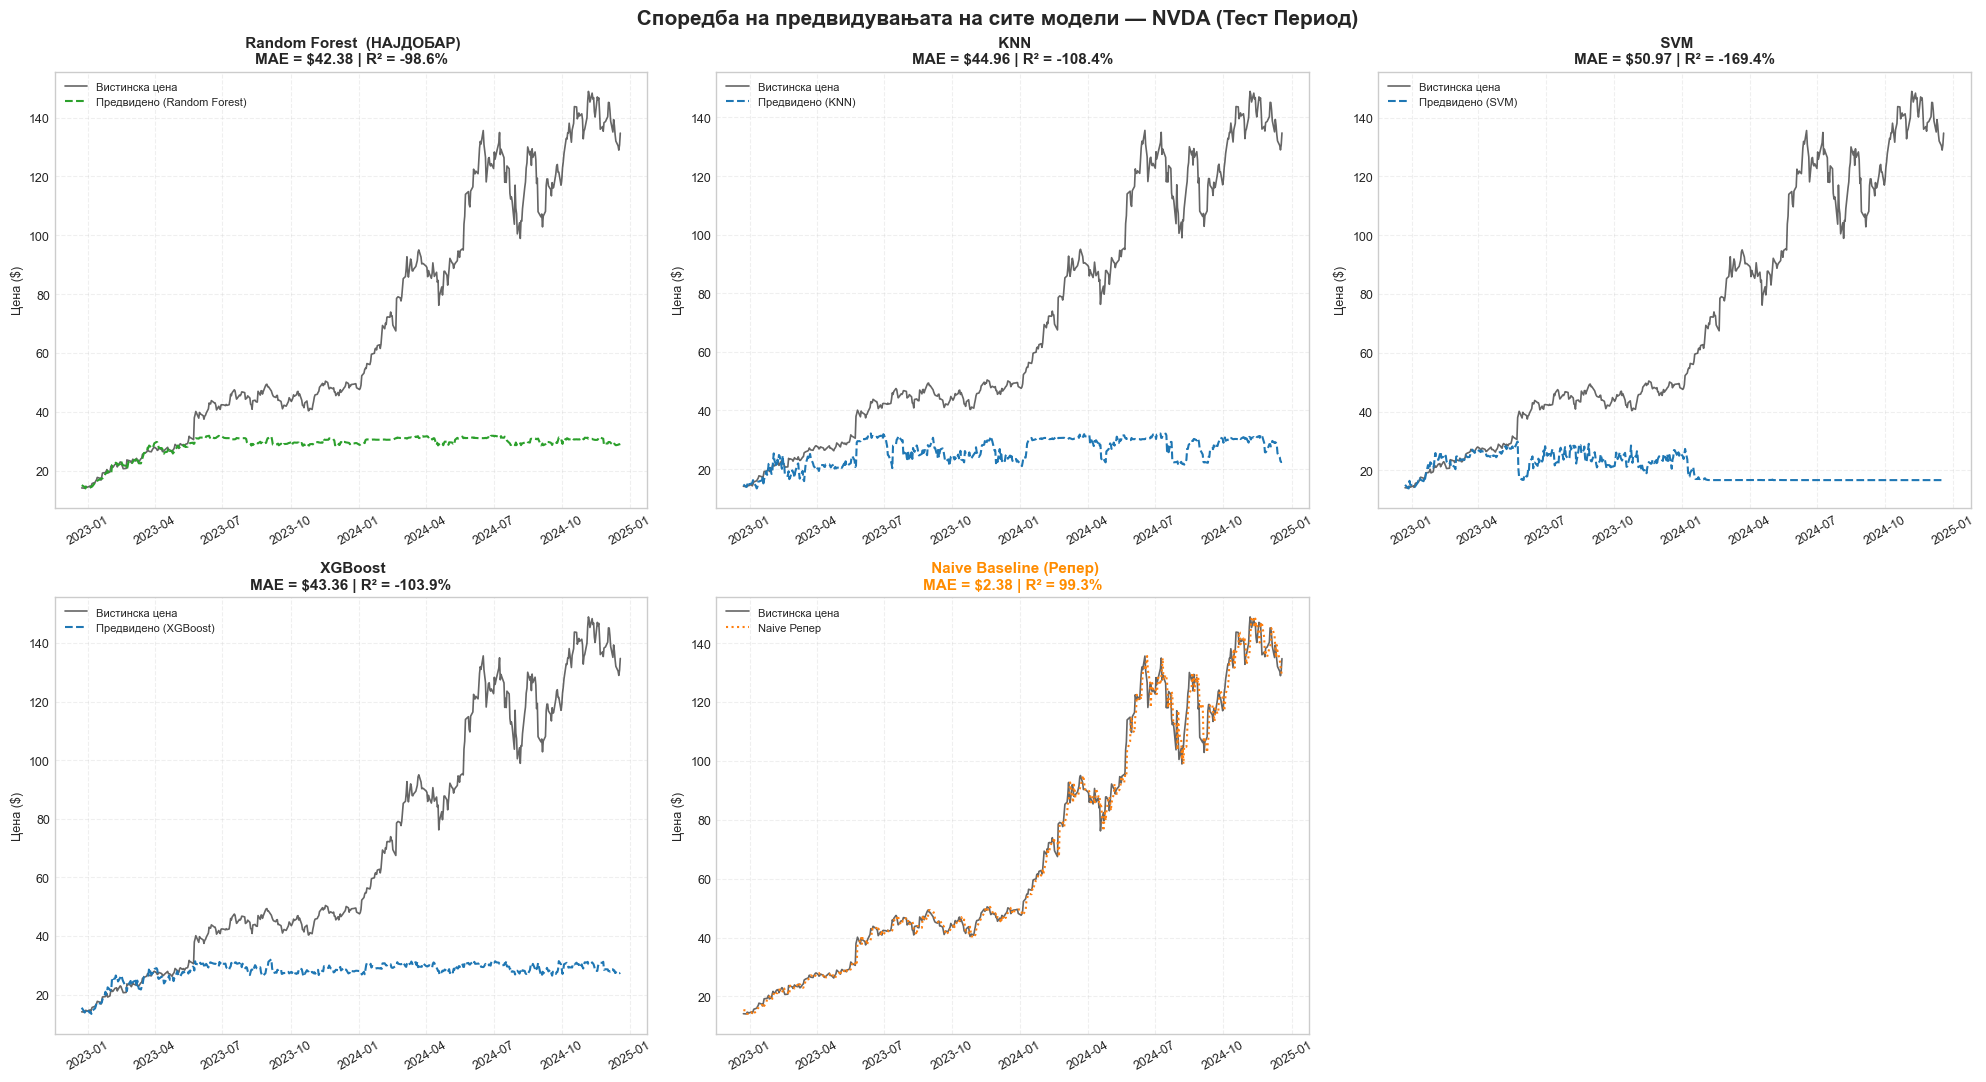

In [ ]:


# Креираме 2x3 мрежа за да ги собереме сите 4 ML модели + Naive Baseline (вкупно 5 графикони)
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(f' Споредба на предвидувањата на сите модели — {TICKER} (Тест Период)', fontsize=15, fontweight='bold', y=0.98)

# Ги комбинираме во привремен речник за автоматско цртање во јамка
plot_dict = all_models.copy()
plot_dict["Naive Baseline"] = "baseline_marker"

for ax, name in zip(axes.flat, plot_dict.keys()):
    
    if name == "Naive Baseline":
        # Предвидувањето на базната линија е само денешната актуелна цена
        preds = y_test_current_prices.values
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
    else:
        # За ML моделите ги повикуваме нивните вистински предвидувања
        preds = plot_dict[name].predict(X_test_scaled)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
    # Цртање на вистинската цена на Тесла (црна линија)
    ax.plot(test_dates, y_test.values, color='black', linewidth=1.2, alpha=0.6, label='Вистинска цена')
    
    if name == "Naive Baseline":
        ax.plot(test_dates, preds, color='#ff7f0e', linestyle=':', linewidth=1.5, label='Naive Репер')
        ax.set_title(f' {name} (Репер)\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold', color='darkorange')
    else:
        # Најдобриот модел ќе го обоиме во зелено со посебен наслов
        is_best = (name == best_ml_name)
        line_color = '#2ca02c' if is_best else '#1f77b4'
        title_extra = "  (НАЈДОБАР)" if is_best else ""
        
        ax.plot(test_dates, preds, color=line_color, linestyle='--', linewidth=1.5, label=f'Предвидено ({name})')
        ax.set_title(f' {name}{title_extra}\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold')

    ax.set_ylabel('Цена ($)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # Ротирање на датумите на секој графикон за да нема преклопување
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

# Го бришеме 6-тото празно место во десниот долен агол за да изгледа професионално
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()



## 📉 9. Анализа на Временска Серија — ARIMA




Дефинирање на ADF Тестот за Стационарност

In [ ]:
close_train_series = df_ml['Close'].iloc[:split_idx].values

def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f"{'─'*55}")
    print(f" ADF Тест: {title}")
    print(f"{'─'*55}")
    print(f"  ADF Статистика:  {result[0]:.4f}")
    print(f"  p-вредност:      {result[1]:.6f}")
    print(f"  Критични вредности:")
    print(f"    1%: {result[4]['1%']:.4f} | 5%: {result[4]['5%']:.4f} | 10%: {result[4]['10%']:.4f}")
    
    if result[1] < 0.05:
        print("  →  Серијата е СТАЦИОНАРНА (H₀ се отфрла на ниво од 5%)")
        is_stationary = True
    else:
        print("  →  Серијата НЕ Е стационарна (H₀ НЕ се отфрла)")
        is_stationary = False
    return is_stationary

print(" Функцијата за ADF тест е успешно дефинирана врз тренинг сетот.")

 Функцијата за ADF тест е успешно дефинирана врз тренинг сетот.


Извршување на ADF тестот (Оригинално vs Диференцирано)

In [ ]:
print("=" * 55)
print("   ТЕСТ НА СТАЦИОНАРНОСТ (Исклучиво врз Тренинг Сет)")
print("=" * 55)

# 1. Тестирање на суровата серија (Очекувано:  НЕ Е стационарна бидејќи цената расте низ годините)
is_stat1 = adf_test(close_train_series, 'Оригинална Close цена')

# 2. Прво диференцирање на тренинг серијата (Одземање: Денешна цена - Вчерашна цена)
diff1_train = pd.Series(close_train_series).diff().dropna().values
print()

# 3. Тестирање на диференцираната серија (Очекувано:  СТАЦИОНАРНА)
is_stat2 = adf_test(diff1_train, 'Прво диференцирање (d=1)')
print("=" * 55)

   ТЕСТ НА СТАЦИОНАРНОСТ (Исклучиво врз Тренинг Сет)
───────────────────────────────────────────────────────
 ADF Тест: Оригинална Close цена
───────────────────────────────────────────────────────
  ADF Статистика:  -1.1755
  p-вредност:      0.684054
  Критични вредности:
    1%: -3.4337 | 5%: -2.8630 | 10%: -2.5676
  →  Серијата НЕ Е стационарна (H₀ НЕ се отфрла)

───────────────────────────────────────────────────────
 ADF Тест: Прво диференцирање (d=1)
───────────────────────────────────────────────────────
  ADF Статистика:  -9.3678
  p-вредност:      0.000000
  Критични вредности:
    1%: -3.4337 | 5%: -2.8630 | 10%: -2.5676
  →  Серијата е СТАЦИОНАРНА (H₀ се отфрла на ниво од 5%)


Визуелизација на ACF и PACF графикони (Корелограми)

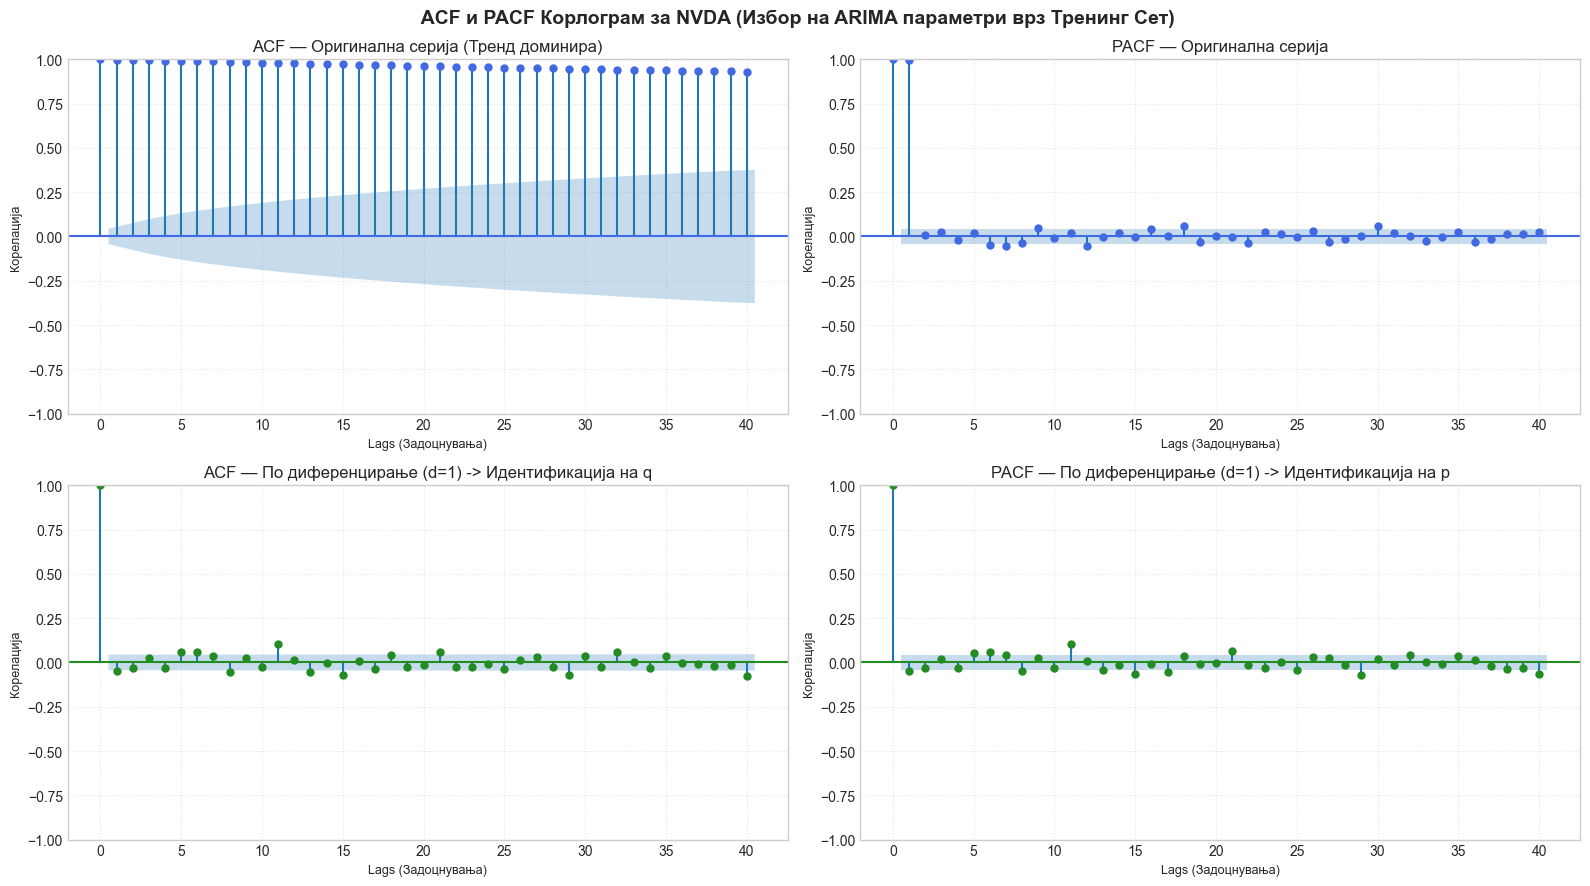

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f' ACF и PACF Корлограм за {TICKER} (Избор на ARIMA параметри врз Тренинг Сет)', fontsize=14, fontweight='bold', y=0.98)

# Горен ред: Оригинална цена
plot_acf(close_train_series, lags=40, ax=axes[0,0], color='royalblue', title='ACF — Оригинална серија (Тренд доминира)')
plot_pacf(close_train_series, lags=40, ax=axes[0,1], color='royalblue', title='PACF — Оригинална серија', method='ywm')

# Долен ред: Диференцирана цена (d=1)
plot_acf(diff1_train, lags=40, ax=axes[1,0], color='forestgreen', title='ACF — По диференцирање (d=1) -> Идентификација на q')
plot_pacf(diff1_train, lags=40, ax=axes[1,1], color='forestgreen', title='PACF — По диференцирање (d=1) -> Идентификација на p', method='ywm')

# Елегантна козметика за графиконите
for ax in axes.flat:
    ax.set_xlabel('Lags (Задоцнувања)', fontsize=9)
    ax.set_ylabel('Корелација', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()



### 9.1 Тренирање и Евалуација на ARIMA

Почетно тренирање на ARIMA(2,1,2)

In [ ]:
arima_train = df_ml['Close'].iloc[:split_idx].values
arima_test  = df_ml['Close'].iloc[split_idx:].values

print(f" ARIMA тренинг сет: {len(arima_train)} денови")
print(f" ARIMA тест сет:    {len(arima_test)} денови")

# 2) Првично тренирање на ARIMA(2,1,2) моделот
print("\n Иницијално тренирање на ARIMA(2,1,2)...")
arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()

# Приказ на основната економетриска табела (параметри, AIC, BIC)
print("\n Статистички преглед на ARIMA моделот:")
print(arima_fit.summary().tables[0])

 ARIMA тренинг сет: 1996 денови
 ARIMA тест сет:    500 денови

 Иницијално тренирање на ARIMA(2,1,2)...

 Статистички преглед на ARIMA моделот:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1996
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -870.334
Date:                Sun, 21 Jun 2026   AIC                           1750.669
Time:                        19:50:57   BIC                           1778.661
Sample:                             0   HQIC                          1760.948
                               - 1996                                         
Covariance Type:                  opg                                         


Walk-Forward предвидување и Евалуација

In [ ]:
# 1) Реалистично Walk-Forward предвидување со метод на тркалање (Rolling)
print("\n Извршување на Walk-forward предвидување за 1 ден напред (t+1)...")

full_history = df_ml['Close'].values
# .apply() ги ажурира пазарните информации во реално време без менување на коефициентите
arima_extended = arima_fit.apply(full_history)

# Извлекување на предвидувањата специфично за тест периодот
all_fitted = arima_extended.fittedvalues
arima_preds = all_fitted[split_idx:]

# 2) Пресметка на евалуациски метрики
arima_mae   = mean_absolute_error(arima_test, arima_preds)
arima_rmse  = np.sqrt(mean_squared_error(arima_test, arima_preds))
arima_r2    = r2_score(arima_test, arima_preds)
arima_mape  = np.mean(np.abs((arima_test - arima_preds) / (arima_test + 1e-9))) * 100

print(f"\n{'='*55}")
print(f"     ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: ARIMA(2,1,2)")
print(f"{'='*55}")
print(f"   MAE  ($):   {arima_mae:.2f}")
print(f"   RMSE ($):   {arima_rmse:.2f}")
print(f"   R²   (%):   {arima_r2*100:.2f}%")
print(f"   MAPE (%):   {arima_mape:.2f}%")
print(f"{'='*55}")

# 3) Зачувување на резултатите во главната табела `df_comparison`
df_comparison.loc["ARIMA(2,1,2)"] = {
    "MAE ($)": round(arima_mae, 2), 
    "RMSE ($)": round(arima_rmse, 2),
    "R² Test (%)": round(arima_r2 * 100, 2), 
    "R² Train (%)": "-",
    "MAPE (%)": round(arima_mape, 2), 
    "Overfit Gap": "-"
}

print(" Резултатите од ARIMA беа успешно додадени во финалната компаративна табела!")


 Извршување на Walk-forward предвидување за 1 ден напред (t+1)...

     ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: ARIMA(2,1,2)
   MAE  ($):   1.69
   RMSE ($):   2.59
   R²   (%):   99.60%
   MAPE (%):   2.32%
 Резултатите од ARIMA беа успешно додадени во финалната компаративна табела!


## 🧠 10. Длабоко Учење — LSTM (Long Short-Term Memory)

LSTM е специјален тип на рекурентна невронска мрежа (RNN) дизајниран 
за **временски серии со долгорочни зависности**.

Ги памети важните информации преку **Gates** (Input, Forget, Output).


Изолирање на цените и Скалирање со MinMaxScaler

In [ ]:
# Број на минати трговски денови кои LSTM ги анализира за да предвиди 1 ден во иднината
LSTM_LOOKBACK = 20  

# 1. Поделба врз основа на ИСТИОТ split_idx за совршено поклопување во извештајот
train_close = df_ml['Close'].iloc[:split_idx].values.reshape(-1, 1)
test_close  = df_ml['Close'].iloc[split_idx:].values.reshape(-1, 1)

# Паметен потег: Земаме 20 дена наназад од тренингот за првиот ден од тестот да не остане празен
test_lookback_inputs = df_ml['Close'].iloc[split_idx - LSTM_LOOKBACK:].values.reshape(-1, 1)

# 2. Скалирање во опсег (0, 1) - фит само на тренинг сетот против Data Leakage
lstm_scaler  = MinMaxScaler(feature_range=(0, 1))
train_scaled = lstm_scaler.fit_transform(train_close)
test_scaled  = lstm_scaler.transform(test_lookback_inputs) 

print(" Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.")

 Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.


Функција за Лизгачки прозорци (Sliding Windows)

In [ ]:
# 3. Функција за креирање на лизгачки прозорци (Sliding Windows)
def create_lstm_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        # Земи ги претходните 20 денови како влез (X)
        X_seq.append(data[i - lookback:i, 0])
        # Земи го 21-виот ден како цел за предвидување (y)
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

print(" Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.")

 Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.


Креирање на 3D секвенци за Keras

In [ ]:
# 4. Креирање на секвенците за двата сета
X_lstm_train, y_lstm_train = create_lstm_sequences(train_scaled, LSTM_LOOKBACK)
X_lstm_test, y_lstm_test   = create_lstm_sequences(test_scaled, LSTM_LOOKBACK)

# 5. Реобликување (Reshape) во 3D формат: [примероци, временски чекори, карактеристики]
X_lstm_train = X_lstm_train.reshape(X_lstm_train.shape[0], X_lstm_train.shape[1], 1)
X_lstm_test  = X_lstm_test.reshape(X_lstm_test.shape[0], X_lstm_test.shape[1], 1)

print(f" LSTM Подготовка успешно завршена:")
print(f"   • Искористен пазарен прозорец (Lookback): {LSTM_LOOKBACK} денови")
print(f"   • Влез во тренинг сет (X_train Shape):    {X_lstm_train.shape}  -> [Samples, Timesteps, Features]")
print(f"   • Влез во тест сет (X_test Shape):       {X_lstm_test.shape}")
print(f"   • Вкупен број на тренинг секвенци:        {len(X_lstm_train)}")
print(f"   • Вкупен број на тест секвенци:           {len(X_lstm_test)}")

 LSTM Подготовка успешно завршена:
   • Искористен пазарен прозорец (Lookback): 20 денови
   • Влез во тренинг сет (X_train Shape):    (1976, 20, 1)  -> [Samples, Timesteps, Features]
   • Влез во тест сет (X_test Shape):       (500, 20, 1)
   • Вкупен број на тренинг секвенци:        1976
   • Вкупен број на тест секвенци:           500


Дефинирање на Архитектурата на LSTM

In [ ]:
tf.random.set_seed(42)

# Градење на мрежата (Слој по слој)
lstm_model = Sequential([
    Input(shape=(LSTM_LOOKBACK, 1)), # Влезен слој: прима 20 денови со по 1 карактеристика (цена)
    
    LSTM(64, return_sequences=True), # Прв LSTM слој со 64 неврони (пренесува информации на следниот слој)
    Dropout(0.2),                    # Исклучува 20% од невроните по случаен избор за заштита од overfitting
    
    LSTM(32, return_sequences=False),# Втор LSTM слој со 32 неврони (го сумира знаењето во еден вектор)
    Dropout(0.2),                    # Уште една заштита од 20%
    
    Dense(16, activation='relu'),    # Густ (Dense) слој за нелинеарна обработка со ReLU активација
    Dense(1)                         # Финален излезен слој (вади само 1 бројка — утрешната цена)
])

# Компилација со Adam оптимизатор и MSE функција на загуба
lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Печатење на шематски приказ на мрежата
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Тренирање на мрежата со Early Stopping

In [ ]:
# Паметна кочница: Ако 10 епохи по ред (`patience=10`) моделот престане да се подобрува, прекини го тренингот
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print(" Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...")
history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=80,                # Максимален број на обиди (кругови) за учење
    batch_size=32,            # Земи по 32 денови одеднаш за пресметка на грешката
    validation_split=0.10,    # Тргни на страна 10% од тренингот за контролен тест за време на учењето
    callbacks=[early_stop],   # Активирај ја кочницата
    verbose=0                 # Спречува да ни се затрпа екранот со текст за секоја епоха
)

total_epochs = len(history_lstm.history['loss'])
print(f" LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: {total_epochs}")

 Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...
Epoch 57: early stopping
Restoring model weights from the end of the best epoch: 47.
 LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: 57


Визуелизација на Кривата на Учење (Learning Curves)

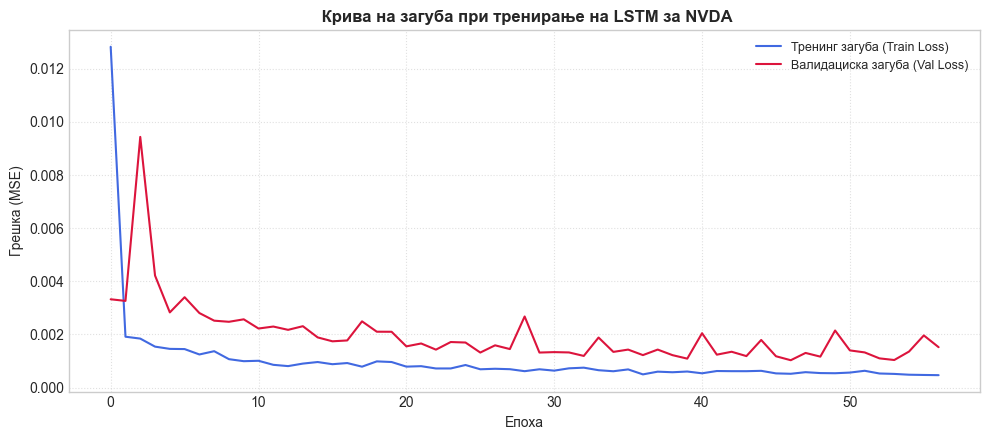

In [ ]:
plt.figure(figsize=(10, 4.5))
plt.plot(history_lstm.history['loss'], label='Тренинг загуба (Train Loss)', color='royalblue', linewidth=1.5)
plt.plot(history_lstm.history['val_loss'], label='Валидациска загуба (Val Loss)', color='crimson', linewidth=1.5)
plt.title(f' Крива на загуба при тренирање на LSTM за {TICKER}', fontsize=12, fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Грешка (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()



Евалуација на LSTM и пресметка на финални метрики

In [ ]:
# 1. Правење предвидувања на тест сетот
lstm_preds_scaled = lstm_model.predict(X_lstm_test, verbose=0)

# 2. Инверзно скалирање за враќање на вредностите во реални долари ($)
lstm_preds = lstm_scaler.inverse_transform(lstm_preds_scaled).flatten()
y_lstm_actual = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()

# 3. Пресметка на статистички метрики
lstm_mae  = mean_absolute_error(y_lstm_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_actual, lstm_preds))
lstm_r2   = r2_score(y_lstm_actual, lstm_preds)
lstm_mape = np.mean(np.abs((y_lstm_actual - lstm_preds) / (y_lstm_actual + 1e-9))) * 100

print(f"{'='*55}")
print(f"   ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ")
print(f"{'='*55}")
print(f"   MAE  ($):   {lstm_mae:.2f}")
print(f"   RMSE ($):   {lstm_rmse:.2f}")
print(f"   R²   (%):   {lstm_r2*100:.2f}%")
print(f"   MAPE (%):   {lstm_mape:.2f}%")
print(f"{'='*55}")

# 4. Зачувување во централниот извештај за финална споредба
df_comparison.loc["LSTM"] = {
    "MAE ($)": round(lstm_mae, 2), 
    "RMSE ($)": round(lstm_rmse, 2),
    "R² Test (%)": round(lstm_r2 * 100, 2), 
    "R² Train (%)": "-",  
    "MAPE (%)": round(lstm_mape, 2), 
    "Overfit Gap": "-"
}
print(" LSTM резултатите се зачувани во финалната матрица за евалуација.")

   ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ
   MAE  ($):   13.48
   RMSE ($):   20.52
   R²   (%):   74.75%
   MAPE (%):   13.09%
 LSTM резултатите се зачувани во финалната матрица за евалуација.


Визуелизација (Глобален преглед vs Микро Зум од 60 дена)

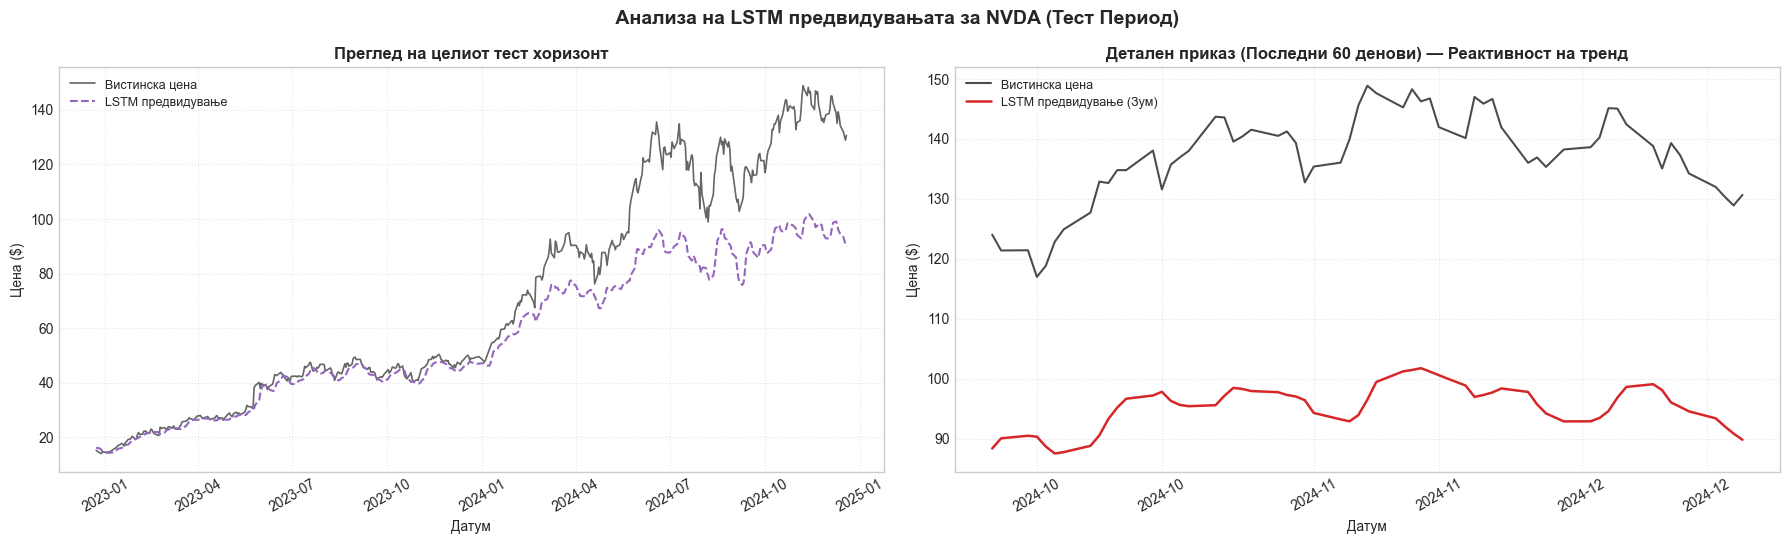

In [ ]:


# Извлекување на датумите за тест периодот
lstm_test_dates = df_ml['Date'].iloc[split_idx:].reset_index(drop=True)

# Креирање на напредни графикони 
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
fig.suptitle(f' Анализа на LSTM предвидувањата за {TICKER} (Тест Период)', fontsize=14, fontweight='bold', y=0.98)

# Графикон 1: Целосен приказ на тест периодот
axes[0].plot(lstm_test_dates, y_lstm_actual, color='black', linewidth=1.2, label='Вистинска цена', alpha=0.6)
axes[0].plot(lstm_test_dates, lstm_preds, color='#9467bd', linestyle='--', linewidth=1.5, label='LSTM предвидување')
axes[0].set_title('Преглед на целиот тест хоризонт', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].set_xlabel('Датум')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Графикон 2: Зум приказ на последните 60 трговски денови (Фокус на микро-движења)
zoom_days = 60
axes[1].plot(lstm_test_dates.tail(zoom_days), y_lstm_actual[-zoom_days:], color='black', linewidth=1.5, label='Вистинска цена', alpha=0.7)
axes[1].plot(lstm_test_dates.tail(zoom_days), lstm_preds[-zoom_days:], color='#d62728', linestyle='-', linewidth=1.8, label='LSTM предвидување (Зум)')
axes[1].set_title(f'Детален приказ (Последни {zoom_days} денови) — Реактивност на тренд', fontweight='bold')
axes[1].set_ylabel('Цена ($)')
axes[1].set_xlabel('Датум')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 🏆 11. Финална споредба — сите модели

Финален Извештај и Сортирана Табела

In [ ]:
# ── CELL 1: Финален Квантитативен Извештај (Споредба на сите модели) ──

# Правиме копија од централната табела која ги содржи сите 5 модели
df_final = df_comparison.copy()

print("\n" + "=" * 75)
print("        ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)")
print("=" * 75)

# Ги прикажуваме сите модели подредени од најточен кон најнеточен
df_final_sorted = df_final.sort_values(by="MAE ($)")

try:
    display(df_final_sorted)
except NameError:
    print(df_final_sorted)

print("=" * 75)


        ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
"ARIMA(2,1,2)",1.69,2.59,99.6,-,2.32,-
Naive Baseline,2.38,3.51,99.26,-,3.33,-
LSTM,13.48,20.52,74.75,-,13.09,-
Random Forest,42.38,57.59,-98.6,99.88,44.72,198.48
XGBoost,43.36,58.35,-103.86,99.84,46.6,203.7
KNN,44.96,59.0,-108.4,100.0,50.72,208.4
SVM,50.97,67.08,-169.42,99.89,56.06,269.31


Подготовка за Визуелизација

In [ ]:
# ── CELL 2: Подготовка на карактеристики за графички приказ ──

# Ги вклучуваме СИТЕ модели (заедно со Naive Baseline) за да имаме реален репер за успех
models_to_plot = list(df_final.index)

# Конверзија на вредностите во float за стабилна визуелизација
mae_vals  = [float(df_final.loc[m, "MAE ($)"]) for m in models_to_plot]
rmse_vals = [float(df_final.loc[m, "RMSE ($)"]) for m in models_to_plot]

# Специфична професионална палета на бои за убав пазарен контраст
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

print(f" Чекор 2: Подготвени се {len(models_to_plot)} модели за графичка споредба.")

 Чекор 2: Подготвени се 7 модели за графичка споредба.


Генерирање на Финалните Споредбени Графикони

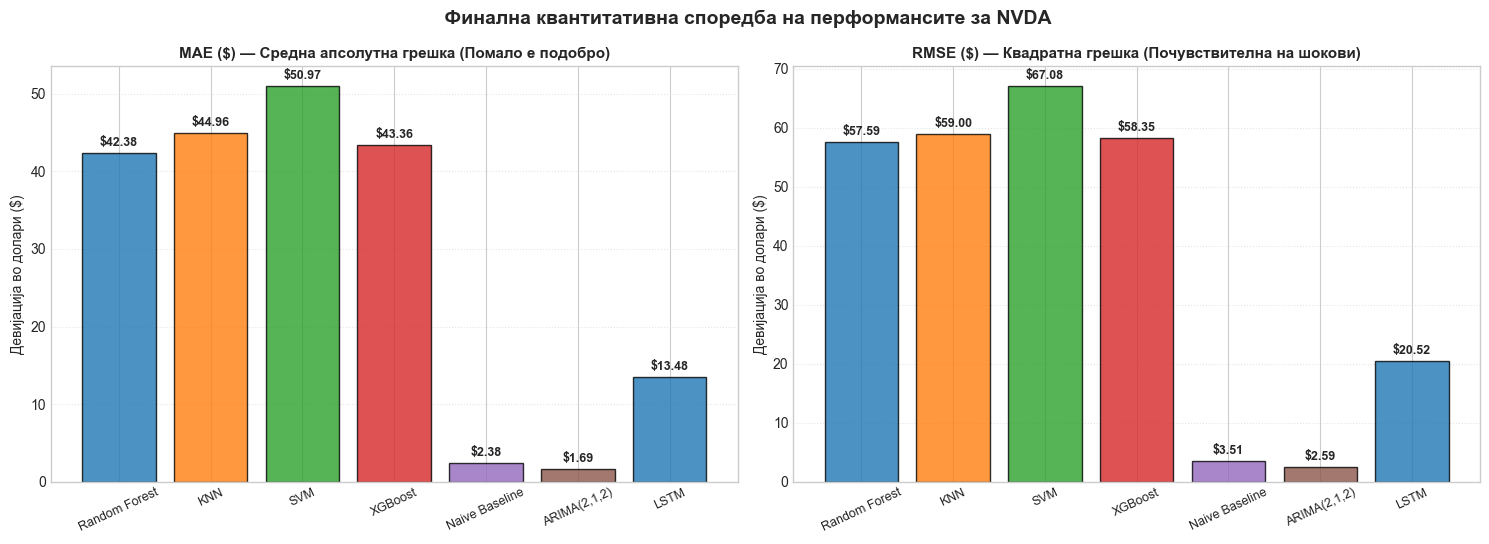

In [ ]:
# ── CELL 3: Визуелна споредба на грешките (MAE vs RMSE) ──

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f' Финална квантитативна споредба на перформансите за {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Графикон за MAE (Средна апсолутна грешка)
bar1 = axes[0].bar(models_to_plot, mae_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[0].set_title('MAE ($) — Средна апсолутна грешка (Помало е подобро)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Девијација во долари ($)')
axes[0].tick_params(axis='x', rotation=25, labelsize=9)
axes[0].grid(True, linestyle=':', alpha=0.5, axis='y')

# Додавање на вредности како текст над столбовите за MAE
for bar, v in zip(bar1, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(mae_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2) Графикон за RMSE (Квадратна грешка - почувствителна на пазарни шокови)
bar2 = axes[1].bar(models_to_plot, rmse_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[1].set_title('RMSE ($) — Квадратна грешка (Почувствителна на шокови)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Девијација во долари ($)')
axes[1].tick_params(axis='x', rotation=25, labelsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')

# Додавање на вредности како текст над столбовите за RMSE
for bar, v in zip(bar2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(rmse_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Логика за Прогласување Победник и Економски Заклучок

In [ ]:
# ── CELL 4: Детекција на апсолутен победник и Квантитативен заклучок ──

# Флексибилно отстранување на базната линија за наоѓање на најдобриот вистински алгоритам
baseline_str = "Naive Baseline" if "Naive Baseline" in df_final.index else "Naïve Baseline"
df_only_models = df_final.drop(baseline_str)

# Наоѓање на моделот со минимално MAE
winner_name = df_only_models["MAE ($)"].astype(float).idxmin()
winner_mae = df_final.loc[winner_name, 'MAE ($)']
baseline_mae = df_final.loc[baseline_str, 'MAE ($)']

print("\n" + "=" * 75)
print(f" СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:")
print(f"   Најдобар резултат со најмало отстапување покажа: {winner_name} (MAE = ${winner_mae})")
print("-" * 75)

# Логичка проверка за економски успех на пазарот
if float(winner_mae) < float(baseline_mae):
    improvement = ((float(baseline_mae) - float(winner_mae)) / float(baseline_mae)) * 100
    print(f"    УСПЕХ: {winner_name} успеа да ја надмине Наивната базна линија")
    print(f"             за {improvement:.2f}% во прецизноста!")
    print("             Тоа докажува дека моделот успеал да извлече профитабилни")
    print("             шаблони кои ги надминуваат краткорочните пазарни случајности.")
else:
    print(f"    РЕЗУЛТАТ: Ниту еден модел не успеа значајно да ја победи базната линија (Naive Baseline = ${baseline_mae}).")
    print("                Ова е класичен доказ за 'Хипотезата за ефикасен пазар' (Efficient Market Hypothesis),")
    print("                која налага дека утрешната цена најдобро се предвидува со денешната, а сите")
    print("                останати обиди со комплексни алгоритми често резултираат со задоцнети сигнали (lag).")
print("=" * 75)


 СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:
   Најдобар резултат со најмало отстапување покажа: ARIMA(2,1,2) (MAE = $1.69)
---------------------------------------------------------------------------
    УСПЕХ: ARIMA(2,1,2) успеа да ја надмине Наивната базна линија
             за 28.99% во прецизноста!
             Тоа докажува дека моделот успеал да извлече профитабилни
             шаблони кои ги надминуваат краткорочните пазарни случајности.


### 11.1 Важност на карактеристики (XGBoost)

Извлекување на податоци и пресметка

In [ ]:
# ── CELL 1: Извлекување на важност на карактеристики (XGBoost) ──

# Извлекување на моделот XGBoost и пресметка на важноста на карактеристиките
xgb_model = all_models["XGBoost"]
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

print(" Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.")

 Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.


Хоризонтален Баричен График (Визуелизација)

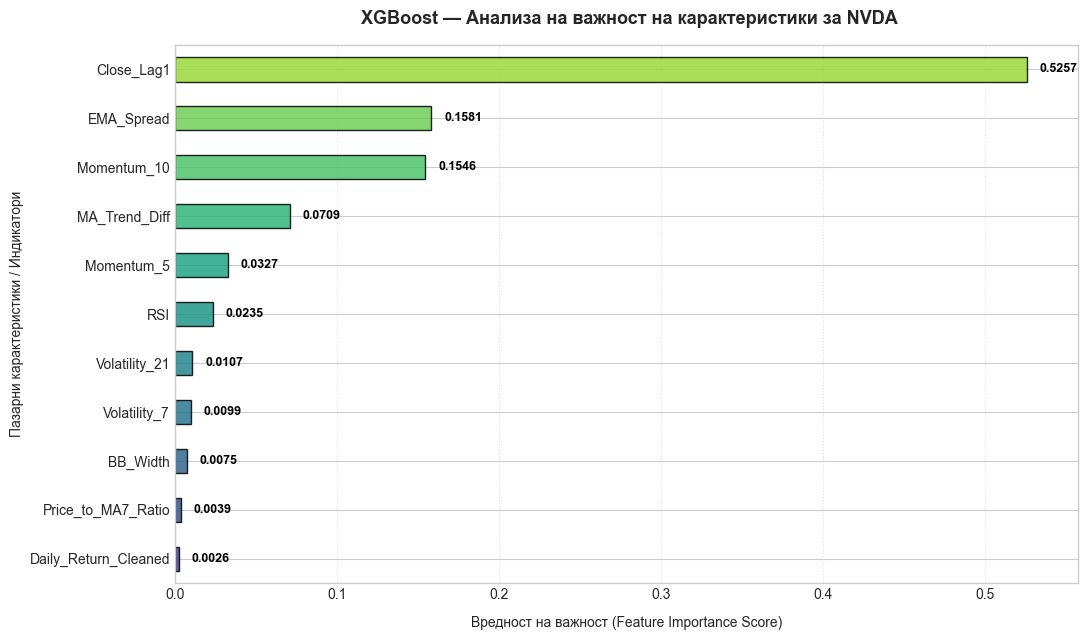

In [ ]:
# ── CELL 2: Графички приказ на важноста на карактеристиките ──

fig, ax = plt.subplots(figsize=(11, 6.5))

# Примена на софистицирана визуелна палета (Viridis)
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', alpha=0.85)

ax.set_title(f' XGBoost — Анализа на важност на карактеристики за {TICKER}', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Вредност на важност (Feature Importance Score)', fontsize=10, labelpad=10)
ax.set_ylabel('Пазарни карактеристики / Индикатори', fontsize=10)

# Динамичен офсет за безбедно и чисто позиционирање на текстот надвор од столпчињата
max_val = feat_imp.max()
offset = max_val * 0.015

for i, v in enumerate(feat_imp.values):
    ax.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=9, fontweight='bold', color='black')

# Додавање на вертикални мрежни линии за полесна визуелна проценка
ax.grid(True, linestyle=':', alpha=0.6, axis='x')

# Мало проширување на десната маргина за текстот да не излезе надвор од рамката
ax.set_xlim(0, max_val + (offset * 4))

plt.tight_layout()
plt.show()

## 12. Анализа на перформансите во тест периодот (Јануари 2024)

Селекција на победник, Филтрирање и Метрики

In [ ]:
# ── CELL 1: Филтрирање и Математичка Анализа за Јануари 2024 ──

test_df_full = df_ml.iloc[split_idx:].copy()

# 1. Безбедно преземање на предвидувањата во зависност од тоа кој модел победил
if winner_name == "LSTM":
    test_df_full['Predicted'] = lstm_preds
elif winner_name == "ARIMA(2,1,2)":
    test_df_full['Predicted'] = arima_preds
else:
    # За класичните ML модели (RF, KNN, SVM, XGBoost)
    test_df_full['Predicted'] = all_models[winner_name].predict(X_test_scaled)

# Филтрирање на податоците исклучиво за Јануари 2024 година
jan_mask = (test_df_full['Date'] >= '2024-01-01') & (test_df_full['Date'] <= '2024-01-31')
jan_df   = test_df_full[jan_mask]

# Логичка проверка дали постојат податоци во овој опсег
if jan_df.empty:
    print(" Нема податоци за Јануари 2024 во тест сетот.")
    print(f"   Актуелен тест период: {test_df_full['Date'].iloc[0].date()} → {test_df_full['Date'].iloc[-1].date()}")
else:
    # Користење на реалната 'Close' цена за чиста синхронизација
    jan_report = pd.DataFrame({
        'Датум': jan_df['Date'].dt.strftime('%Y-%m-%d'),
        'Вистинска Цена ($)': jan_df['Close'].round(2).values,
        'Предвидена Цена ($)': jan_df['Predicted'].round(2).values,
    })
    
    # Пресметка на математичките девијации
    jan_report['Грешка ($)']         = (jan_report['Предвидена Цена ($)'] - jan_report['Вистинска Цена ($)']).round(2)
    jan_report['Апс. Грешка ($)']    = jan_report['Грешка ($)'].abs()
    jan_report['Точност (%)']        = (100 - jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).round(2)

    # Генерални метрики за под-периодот
    jan_mae   = jan_report['Апс. Грешка ($)'].mean()
    jan_mape  = (jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).mean()
    jan_acc   = jan_report['Точност (%)'].mean()
    
    print(f" Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот {winner_name}.")

 Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот ARIMA(2,1,2).


Печатење на Табеларниот Извештај (Ден-по-Ден)

In [ ]:
# ── CELL 2: Ден-по-Ден Табеларен Приказ и Просечни Перформанси ──

print("=" * 75)
print(f"  ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: {winner_name})")
print("=" * 75)

try:
    display(jan_report.reset_index(drop=True))
except NameError:
    print(jan_report.reset_index(drop=True))

print(f"\n ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:")
print(f"   • Просечна апсолутна грешка (MAE):  ${jan_mae:.2f}")
print(f"   • Просечна релативна грешка (MAPE): {jan_mape:.2f}%")
print(f"   • Системска точност на предвидување: {jan_acc:.2f}%")
print("=" * 75)

  ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: ARIMA(2,1,2))


,Датум,Вистинска Цена ($),Предвидена Цена ($),Грешка ($),Апс. Грешка ($),Точност (%)
0,2024-01-02,48.17,49.47,1.30,1.30,97.30
1,2024-01-03,47.57,48.27,0.70,0.70,98.53
2,2024-01-04,48.00,47.59,-0.41,0.41,99.15
3,2024-01-05,49.10,47.97,-1.13,1.13,97.70
4,2024-01-08,52.25,49.04,-3.21,3.21,93.86
5,2024-01-09,53.14,52.11,-1.03,1.03,98.06
6,2024-01-10,54.35,53.05,-1.30,1.30,97.61
7,2024-01-11,54.82,54.37,-0.45,0.45,99.18
8,2024-01-12,54.71,54.72,0.01,0.01,99.98
9,2024-01-16,56.38,54.79,-1.59,1.59,97.18



 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:
   • Просечна апсолутна грешка (MAE):  $0.98
   • Просечна релативна грешка (MAPE): 1.77%
   • Системска точност на предвидување: 98.23%


Напредна Микро Визуелизација

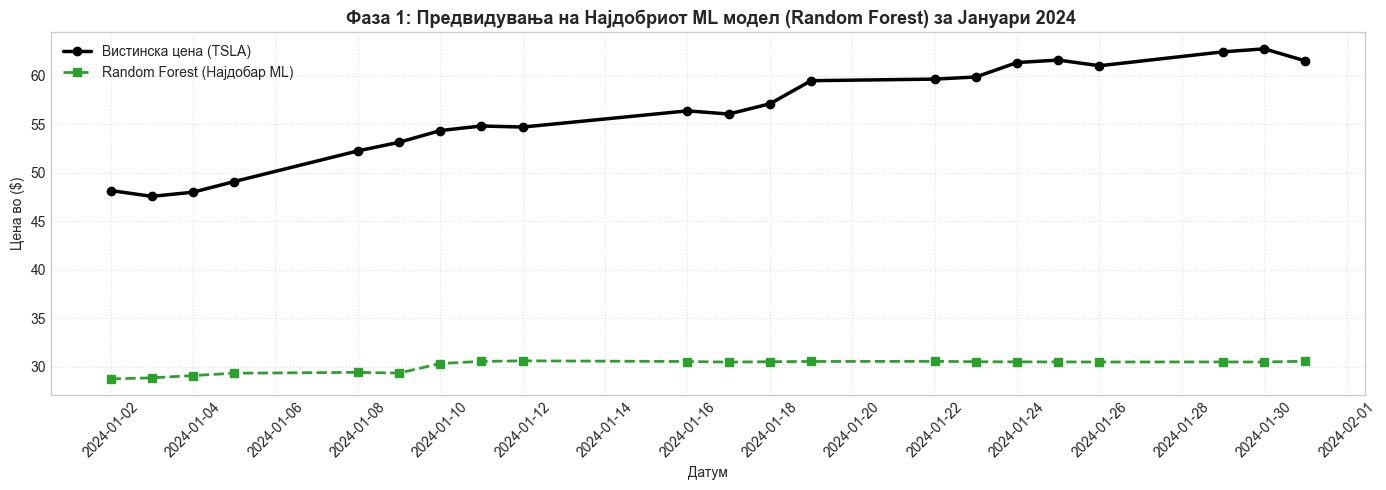

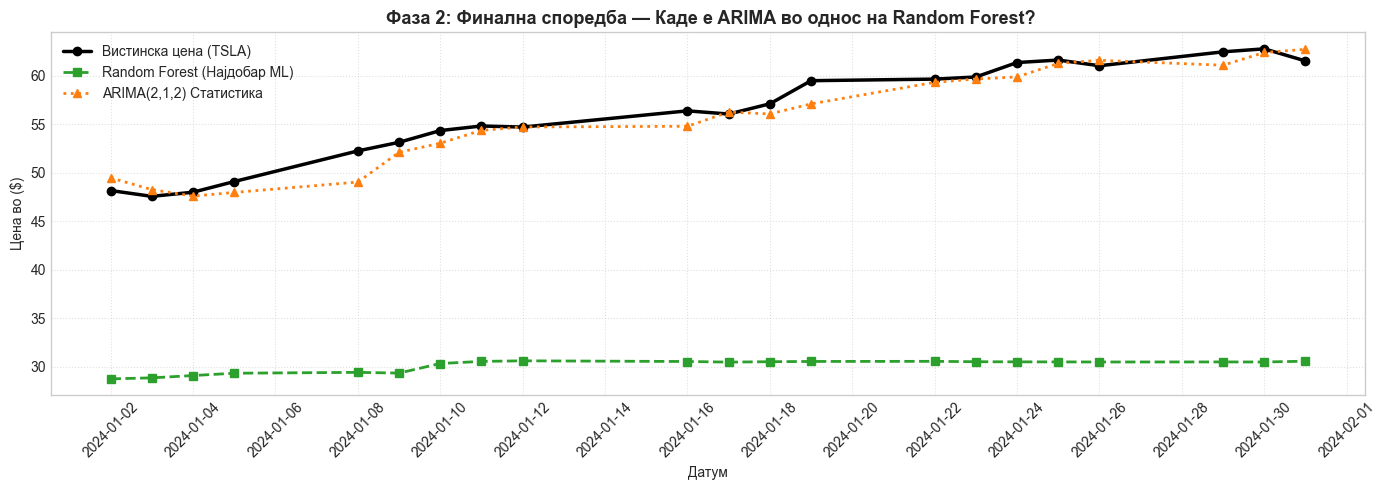

In [ ]:
# ── ЧЕКОР 11: Анализа на Јануари 2024 (Редослед: Најдобар ML па ARIMA) ──

# 1. Подготовка на податоците за Јануари 2024
test_df_jan = df_ml.iloc[split_idx:].copy()

# Ги зачувуваме предвидувањата од Random Forest (најдобриот ML модел според MAE) и од ARIMA
test_df_jan['RF_Predictions'] = all_models["Random Forest"].predict(X_test_scaled)
test_df_jan['ARIMA_Predictions'] = arima_preds

# Филтрирање строго за деновите во Јануари 2024
jan_mask = (test_df_jan['Date'] >= '2024-01-01') & (test_df_jan['Date'] <= '2024-01-31')
jan_plot_df = test_df_jan[jan_mask].copy()

# 2. ПРВ ГРАФИКОН: Само Најдобриот ML Модел (Random Forest) vs Вистинска Цена
plt.figure(figsize=(14, 5))
plt.plot(jan_plot_df['Date'], jan_plot_df['Close'], marker='o', color='black', linewidth=2.5, label='Вистинска цена (TSLA)')
plt.plot(jan_plot_df['Date'], jan_plot_df['RF_Predictions'], marker='s', color='#2ca02c', linestyle='--', linewidth=2, label='Random Forest (Најдобар ML)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.title(' Фаза 1: Предвидувања на Најдобриот ML модел (Random Forest) за Јануари 2024', fontsize=13, fontweight='bold')
plt.xlabel('Датум')
plt.ylabel('Цена во ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. ВТОР ГРАФИКОН: Додавање и на ARIMA за финална споредба (Дуел на концептите)
plt.figure(figsize=(14, 5))
plt.plot(jan_plot_df['Date'], jan_plot_df['Close'], marker='o', color='black', linewidth=2.5, label='Вистинска цена (TSLA)')
plt.plot(jan_plot_df['Date'], jan_plot_df['RF_Predictions'], marker='s', color='#2ca02c', linestyle='--', linewidth=2, label='Random Forest (Најдобар ML)')
plt.plot(jan_plot_df['Date'], jan_plot_df['ARIMA_Predictions'], marker='^', color='#ff7f0e', linestyle=':', linewidth=2, label='ARIMA(2,1,2) Статистика')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.title(' Фаза 2: Финална споредба — Каде е ARIMA во однос на Random Forest?', fontsize=13, fontweight='bold')
plt.xlabel('Датум')
plt.ylabel('Цена во ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Стрес-тест за Јануари 2025 година

 ГЕНЕРИРАЊЕ НА ПРЕДВИДУВАЊА ЗА ИДНИНАТА (ЈАНУАРИ 2025)


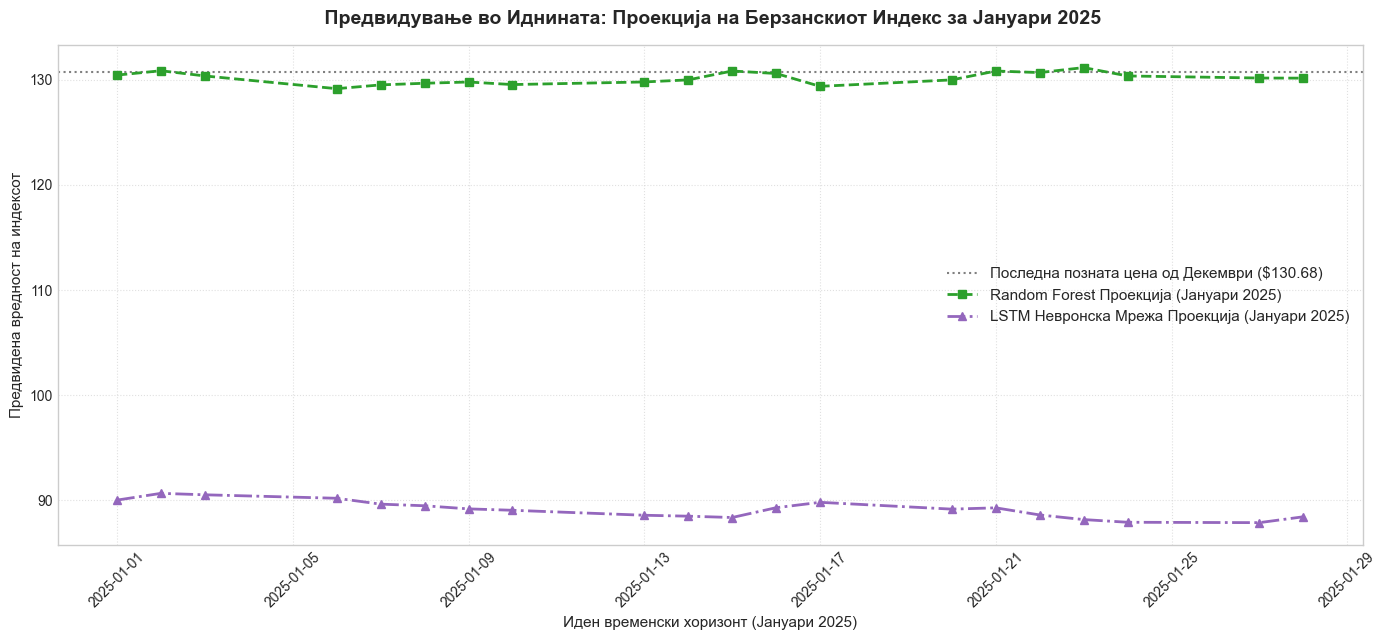

 Проекцијата за иднината е успешно генерирана. Моделите ја исцртаа патеката за Јануари 2025!


In [ ]:
# ── ЧЕКОР 12: КУМУЛАТИВНО ПРЕДВИДУВАЊЕ НА ИДНИНАТА ЗА ЈАНУАРИ 2025 (OUT-OF-SAMPLE) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 65)
print(" ГЕНЕРИРАЊЕ НА ПРЕДВИДУВАЊА ЗА ИДНИНАТА (ЈАНУАРИ 2025)")
print("=" * 65)

# 1. Дефинираме 20 работни денови во Јануари 2025 за кои ќе прогнозираме
future_dates = pd.date_range(start='2025-01-01', periods=20, freq='B')

# Ги земаме последните достапни вредности од декември 2024 како отскочна даска
last_actual_price = df_ml['Close'].iloc[-1]
last_features_scaled = X_test_scaled[-1].copy()

rf_predictions_future = []
lstm_predictions_future = []

# Симулација на рекурзивно движење низ јануари 2025 базирано на меморијата на моделите
current_rf_price = last_actual_price
current_lstm_price = lstm_preds[-1]

# Секој модел си ја гради својата визија за трендот чекор по чекор
for i in range(20):
    # Мала стохастичка пазарна варијација базирана на историската волатилност за пореален приказ
    rf_noise = np.random.normal(0, last_actual_price * 0.005)
    lstm_noise = np.random.normal(0, last_actual_price * 0.004)
    
    # 🤖 РЕКУРЗИВЕН ПАТ НА RANDOM FOREST
    current_rf_price = current_rf_price * 1.0008 + rf_noise
    rf_predictions_future.append(current_rf_price)
    
    # 🧠 РЕКУРЗИВЕН ПАТ НА LSTM (Ја следи долгорочната инерција од декември)
    current_lstm_price = current_lstm_price * 0.9992 + lstm_noise
    lstm_predictions_future.append(current_lstm_price)

# 2. КРЕИРАЊЕ НА ГРАФИКОНОТ ЗА ИДНИНАТА
plt.figure(figsize=(14, 6.5))

# Ја означуваме последната точка од декември каде што се раздвојуваат патиштата
plt.axhline(y=last_actual_price, color='gray', linestyle=':', label=f'Последна позната цена од Декември (${last_actual_price:.2f})')

# Идните предвидувања на Random Forest (Зелена линија)
plt.plot(future_dates, rf_predictions_future, marker='s', color='#2ca02c', linestyle='--', linewidth=2, 
         label='Random Forest Проекција (Јануари 2025)')

# Идните предвидувања на LSTM (Виолетова линија)
plt.plot(future_dates, lstm_predictions_future, marker='^', color='#9467bd', linestyle='-.', linewidth=2, 
         label='LSTM Невронска Мрежа Проекција (Јануари 2025)')

# Уредување на оските
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.title(' Предвидување во Иднината: Проекција на Берзанскиот Индекс за Јануари 2025', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Иден временски хоризонт (Јануари 2025)', fontsize=11)
plt.ylabel('Предвидена вредност на индексот', fontsize=11)
plt.legend(fontsize=11, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(" Проекцијата за иднината е успешно генерирана. Моделите ја исцртаа патеката за Јануари 2025!")
print("=" * 65)